# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 6     |  |
| :-------------|:-------------|
| Moene van der Wiel| 6583733 |
| Erik van den Berkmortel| 6565182 |
| Raphaelle Tam | 6504272 |

In [2]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Moene', 'Erik','Raphaelle']

## Opdracht 1: Planning.

| Planning Groep: 6     |Tijdstip / Tijdspanne  |
|---|---|
| sensor kalibreren | 11:15 |
| test meetingen | 12:00 |
| iteratie 0 | 12:30 |
| iteratie 0 test | 14:00 |
| iteratie 1+ | 14:30 |
| iteratie 1+ test | 15:00 |
| iteratie 2+ | 15:30 |
| iteratie 2+ test | 16:00 |
| final meeting | 16:30 |
| documentatie | 17:00 |
| groep aanwezig 1| 10:45-12:30 |
| groep aanwezig 2| 13:30-17:30 |
| Pauze 1| 10:30-10:45 |
| Pauze 2| 12:30-13:30 |

## Opdracht 2: Import libs.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit


# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [6]
<img src="kalibratie-meetingen.jpg" width="400">

alpha=0.033764625123587466, beta=2.117922896206223


[]

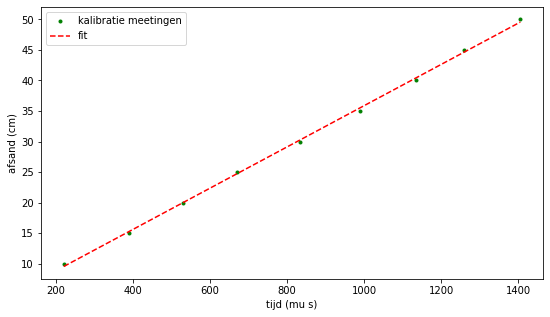

In [4]:
# verwerk hier jullie kalibratiemetingen
tijd = np.array([220,390,530,670,833,990,1134,1260,1405]) #mu s
afstand = np.array([10,15,20,25,30,35,40,45,50]) #cm

def fit_func(t,a,b):
    return a*t + b

var, cov = curve_fit(fit_func,tijd,afstand)

print(f'alpha={var[0]}, beta={var[1]}')

tijd_test = np.linspace(min(tijd),max(tijd),1000)
afstand_fit = fit_func(tijd_test,*var)
plt.figure(figsize=(9,5))
plt.plot(tijd,afstand,'g.',label='kalibratie meetingen')
plt.plot(tijd_test,afstand_fit,'r--',label='fit')
plt.xlabel('tijd (mu s)')
plt.ylabel('afsand (cm)')
plt.legend()
plt.plot()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  46.0
1   0  30   0  20  45.9
2  40   0  30   0  51.0
3  30   0  20   0  51.5


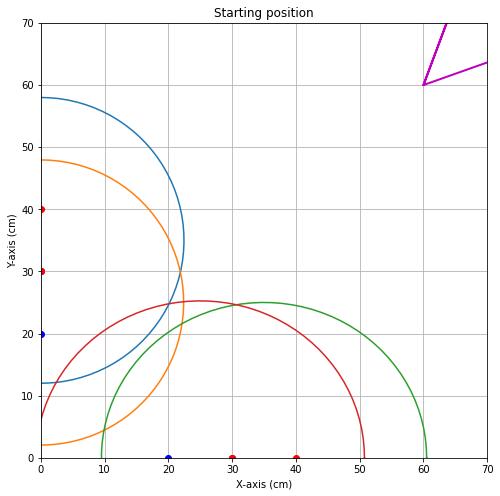


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.355


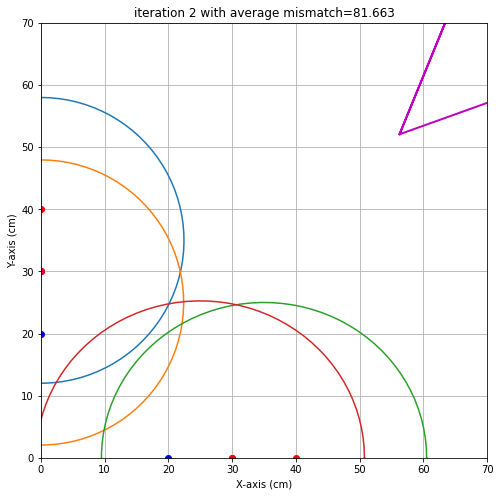

end iteration 2 with average mismatch=81.663


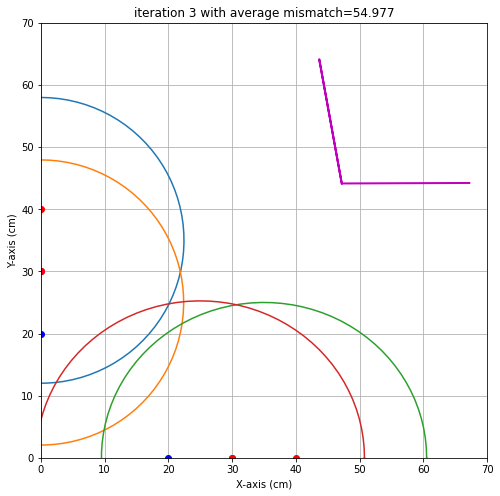

end iteration 3 with average mismatch=54.977


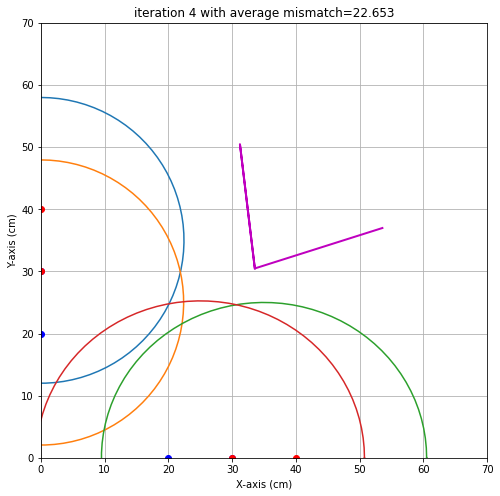

end iteration 4 with average mismatch=22.653


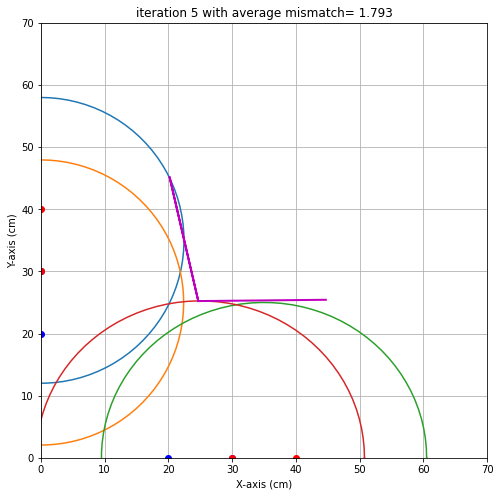

end iteration 5 with average mismatch= 1.793


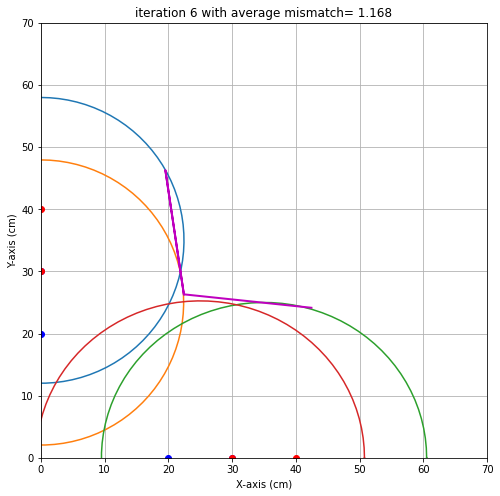

end iteration 6 with average mismatch= 1.168
end iteration 7 with average mismatch= 1.168


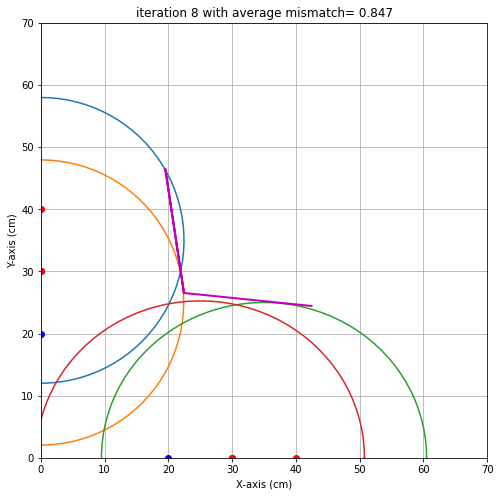

end iteration 8 with average mismatch= 0.847
end iteration 9 with average mismatch= 0.825
end iteration 10 with average mismatch= 0.821
end iteration 11 with average mismatch= 0.821
end iteration 12 with average mismatch= 0.806


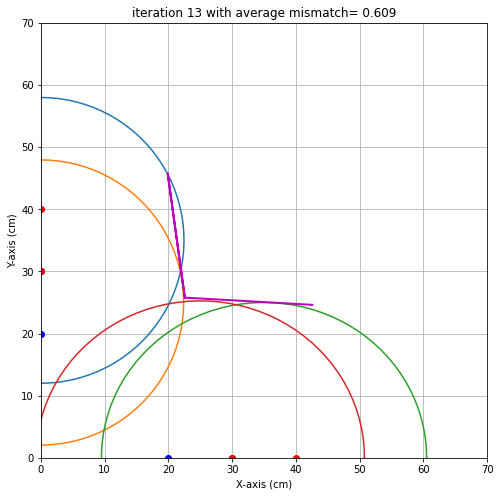

end iteration 13 with average mismatch= 0.609


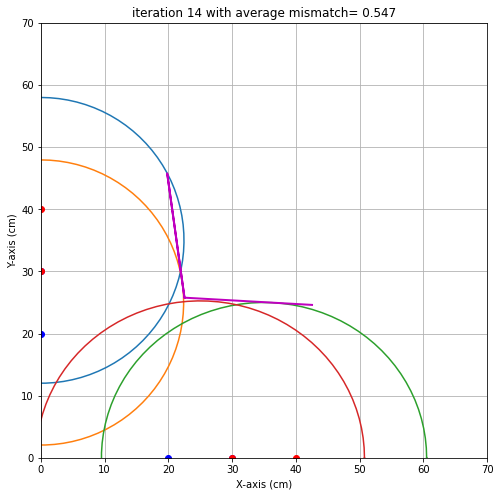

end iteration 14 with average mismatch= 0.547
end iteration 15 with average mismatch= 0.547
end iteration 16 with average mismatch= 0.547
end iteration 17 with average mismatch= 0.547
end iteration 18 with average mismatch= 0.547
end iteration 19 with average mismatch= 0.547
end iteration 20 with average mismatch= 0.547
end iteration 21 with average mismatch= 0.547
end iteration 22 with average mismatch= 0.547
end iteration 23 with average mismatch= 0.547
end iteration 24 with average mismatch= 0.513
end iteration 25 with average mismatch= 0.503
end iteration 26 with average mismatch= 0.503
end iteration 27 with average mismatch= 0.503
end iteration 28 with average mismatch= 0.503
end iteration 29 with average mismatch= 0.503
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.503
###############################################################################
end of iteration  30
Best alp

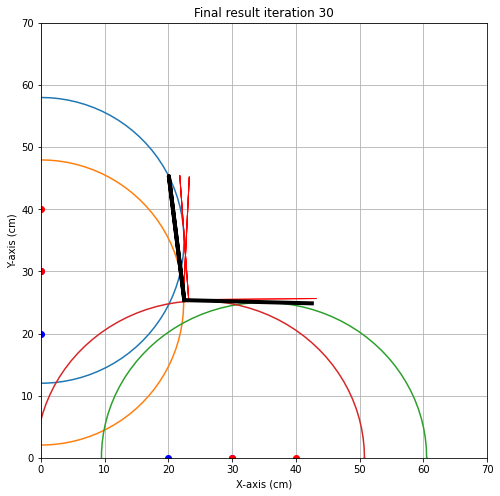

In [5]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,46.0],
    [0,30,0,20,45.9],
    #[0,10,0,20,190],
    [40,0,30,0,51.0],
    [30,0,20,0,51.5],
    #[10,0,20,0,-],
    #[10,0,0,10,163]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [6]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 22.5 cm met een standaardafwijking van 0.7 cm 
y0: 25.4 cm met een standaardafwijking van 0.2 cm 
alpha: -1.5 graden met een standaardafwijking van 2.0 graad 
beta: -6.9 graden met een standaardafwijking van 9.6 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Raphaelle]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="algoritme_raphaelle.jpg" width="400">

#### algoritme [Erik]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="algoritme_erik.jpg" width="400">

#### algoritme [Moene]
Voeg een foto in van het algoritme van het derde groepslid
<img src="algoritme_moene.jpg" width="400">

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  46.0
1   0  30   0  20  45.9
2  40   0  30   0  51.0
3  30   0  20   0  51.5


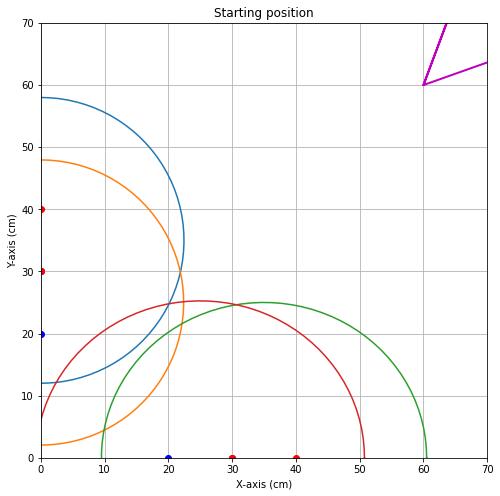


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=93.355
end iteration 2 with average mismatch=86.145


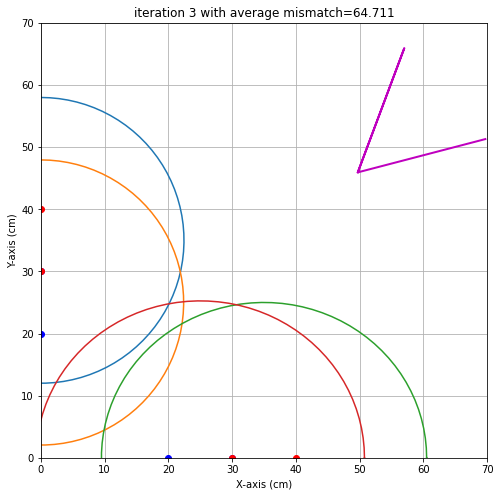

end iteration 3 with average mismatch=64.711


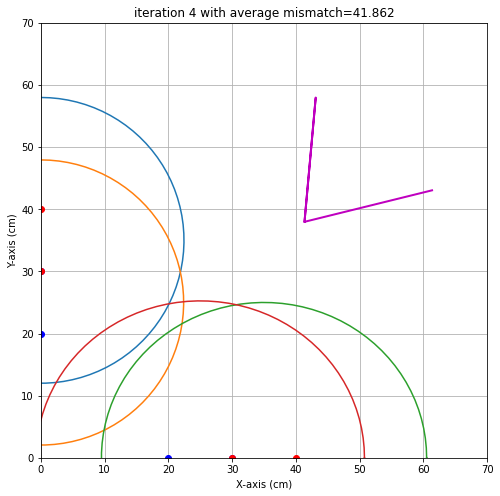

end iteration 4 with average mismatch=41.862


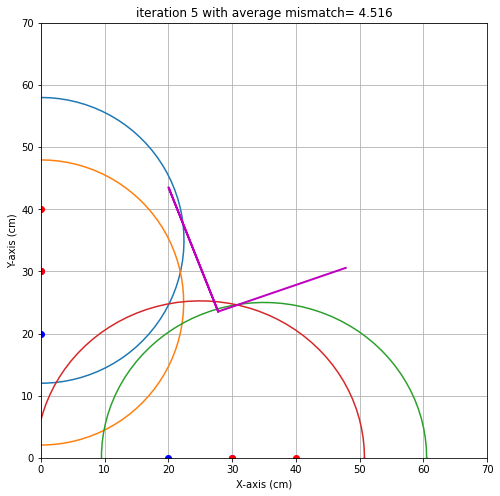

end iteration 5 with average mismatch= 4.516


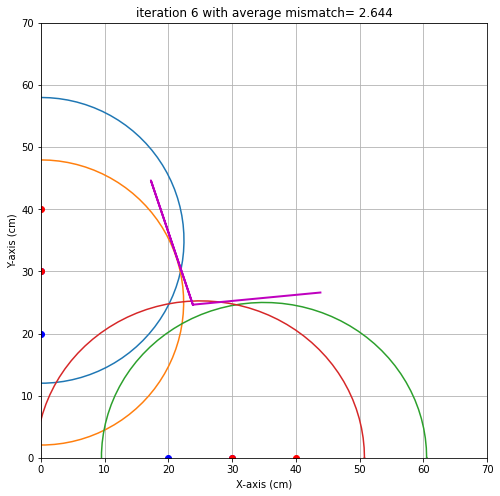

end iteration 6 with average mismatch= 2.644


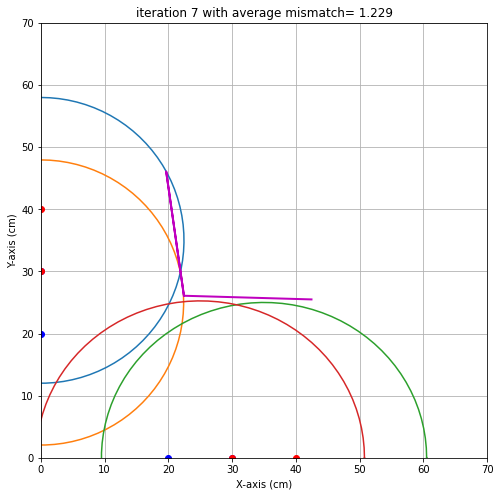

end iteration 7 with average mismatch= 1.229


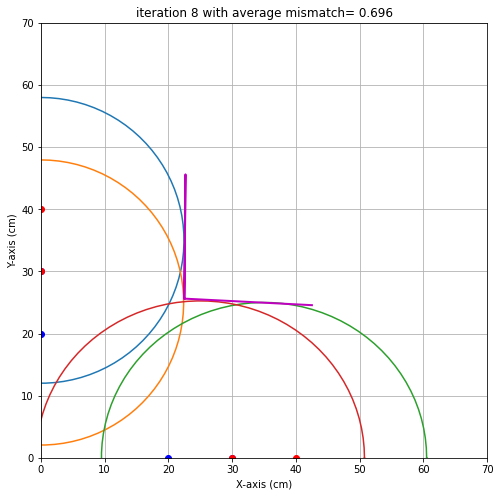

end iteration 8 with average mismatch= 0.696
end iteration 9 with average mismatch= 0.693


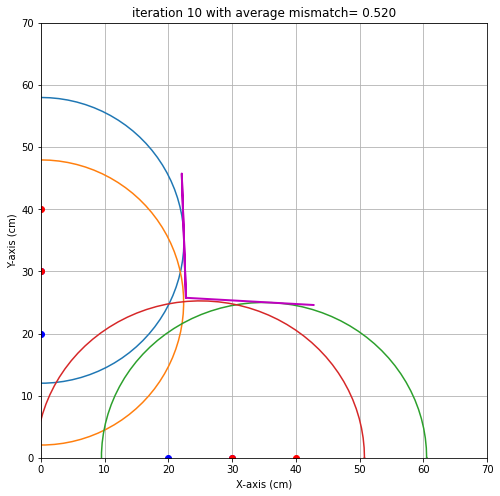

end iteration 10 with average mismatch= 0.520
end iteration 11 with average mismatch= 0.520


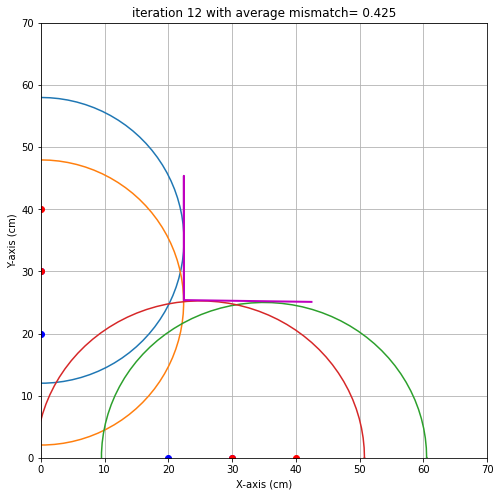

end iteration 12 with average mismatch= 0.425
end iteration 13 with average mismatch= 0.413
end iteration 14 with average mismatch= 0.412
end iteration 15 with average mismatch= 0.411
end iteration 16 with average mismatch= 0.410
end iteration 17 with average mismatch= 0.410
end iteration 18 with average mismatch= 0.410
end iteration 19 with average mismatch= 0.410
end iteration 20 with average mismatch= 0.410
end iteration 21 with average mismatch= 0.410
end iteration 22 with average mismatch= 0.410
end iteration 23 with average mismatch= 0.410
end iteration 24 with average mismatch= 0.410
end iteration 25 with average mismatch= 0.410
end iteration 26 with average mismatch= 0.410
end iteration 27 with average mismatch= 0.410
end iteration 28 with average mismatch= 0.410
end iteration 29 with average mismatch= 0.410
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch

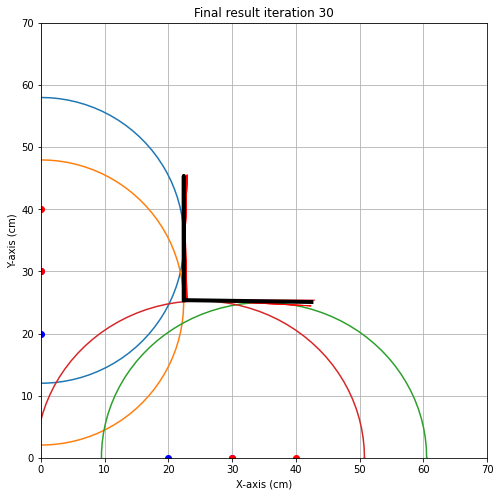

In [7]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

start_meetingen = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,46.0],
    [0,30,0,20,45.9],
    #[0,10,0,20,190],
    [40,0,30,0,51.0],
    [30,0,20,0,51.5],
    #[10,0,20,0,-],
    #[10,0,0,10,163]    
    ])

rough_location = imagingDEF.imagingDEF(start_meetingen)
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']


In [10]:

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')

range s: x=[22.42998027 46.4274161 ], y=[25.37572629 49.37572412]
range r: x=[21.68788521 45.69814466], y=[25.35661727 49.35662598]
s pos: (30.429125546961387,0), (38.42827082105231,0), (0,33.375725568911), (0,41.37572484310726)
r pos: (29.69130502481312,0), (37.694724841976765,0), (0,33.35662016961314), (0,41.356623072828796)


## Opdracht 6: Test iteratie 0.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  50   0  66.63
1  30   0  70   0  80.83
2  50   0  70   0  78.59
3   0  30   0  50  61.77
4   0  30   0  70  75.21


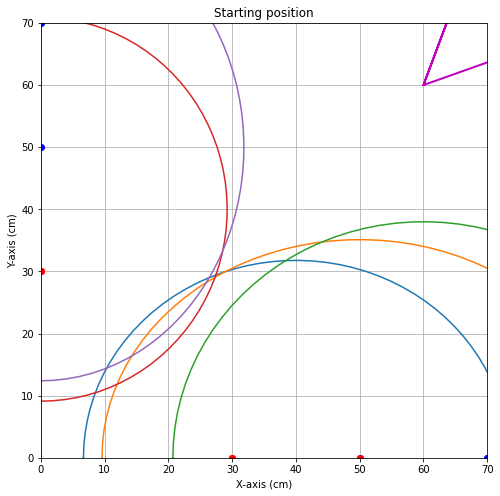


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.789


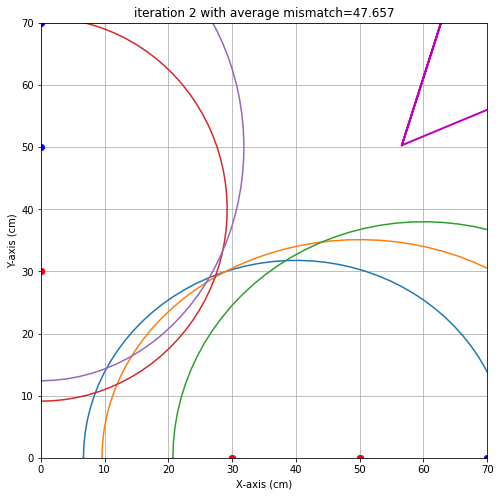

end iteration 2 with average mismatch=47.657


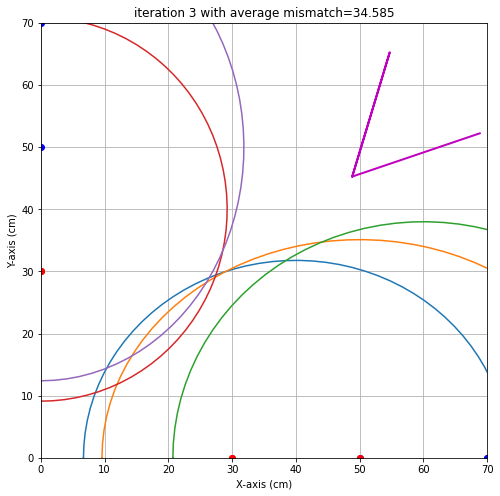

end iteration 3 with average mismatch=34.585


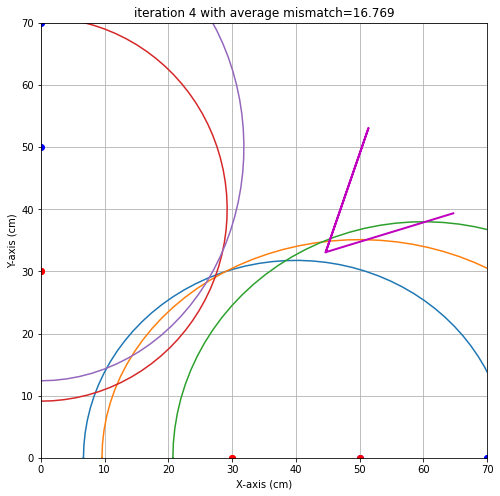

end iteration 4 with average mismatch=16.769


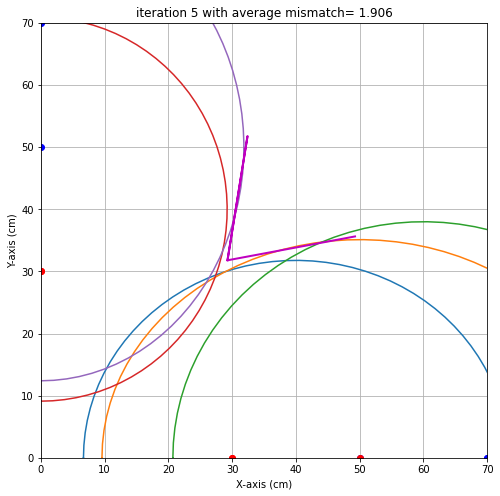

end iteration 5 with average mismatch= 1.906


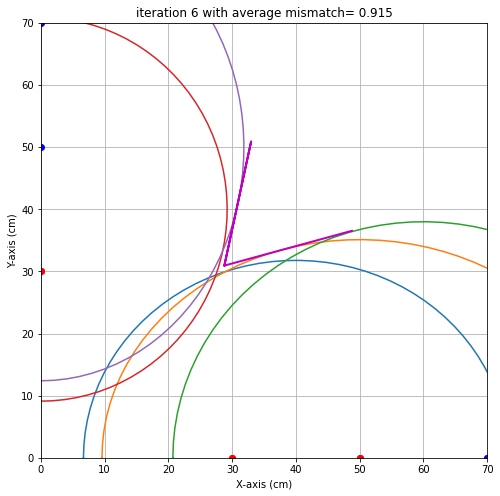

end iteration 6 with average mismatch= 0.915


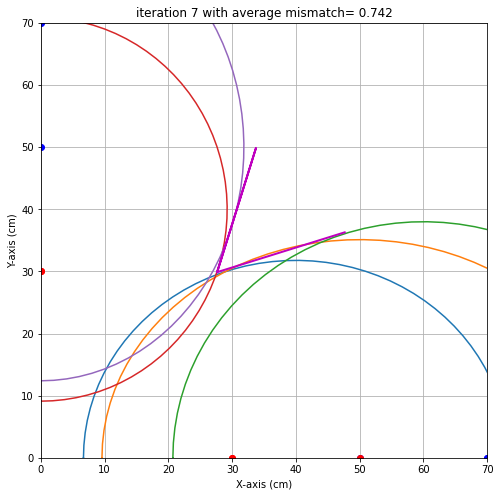

end iteration 7 with average mismatch= 0.742
end iteration 8 with average mismatch= 0.742
end iteration 9 with average mismatch= 0.680
end iteration 10 with average mismatch= 0.663
end iteration 11 with average mismatch= 0.650


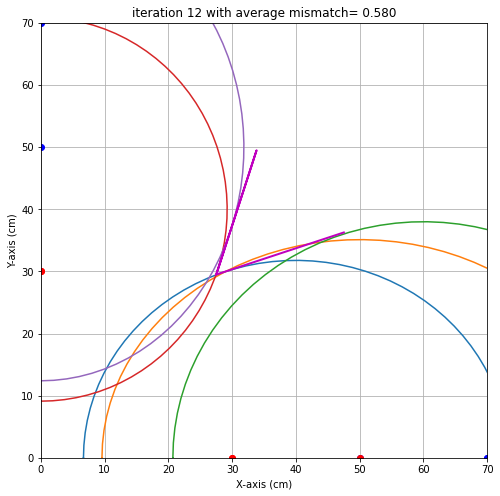

end iteration 12 with average mismatch= 0.580
end iteration 13 with average mismatch= 0.580
end iteration 14 with average mismatch= 0.580
end iteration 15 with average mismatch= 0.580
end iteration 16 with average mismatch= 0.580
end iteration 17 with average mismatch= 0.580
end iteration 18 with average mismatch= 0.580
end iteration 19 with average mismatch= 0.580
end iteration 20 with average mismatch= 0.580
end iteration 21 with average mismatch= 0.580
end iteration 22 with average mismatch= 0.580
end iteration 23 with average mismatch= 0.580
end iteration 24 with average mismatch= 0.580
end iteration 25 with average mismatch= 0.574
end iteration 26 with average mismatch= 0.559
end iteration 27 with average mismatch= 0.558
end iteration 28 with average mismatch= 0.557
end iteration 29 with average mismatch= 0.557
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.557
#################

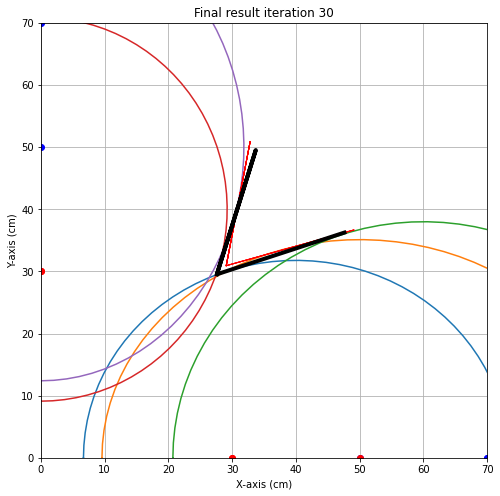

range s: x=[27.60515065 50.35603568], y=[29.53698559 52.49278106]
range r: x=[49.97090087 79.75736712], y=[48.10558371 76.81564311]
s pos: (35.18877899227585,0), (42.77240733430557,0), (0,37.18891741532725), (0,44.84084923672438)
r pos: (59.89972295087285,0), (69.82854503591348,0), (0,57.675603512121064), (0,67.24562331172436)


In [16]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':27,
           'y0':25,
           'alpha' : 10,
           'beta' : 0}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Moene' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,50,0,66.63],
    [30,0,70,0,80.83],
    [50,0,70,0,78.59],
    [0,30,0,50,61.77],
    [0,30,0,70,75.21],
    #[0,50,0,70,-]
    ]),
       'Erik' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,-],
    [35,0,55,0,68.81],
    [50,0,70,0,77.91],
    [0,20,0,40,61.53],
    [0,35,0,55,61.90],
    #[0,45,0,70,-],
    [70,0,45,0,78.21],
    [50,0,65,0,76.51],
    [65,0,35,0,78.85],
    [0,35,0,45,57.12],
    #[0,20,0,50,-],
    [0,45,0,30,59.61]
    ])
      }

rough_location = imagingDEF.imagingDEF(data['Moene'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')

In [19]:
data ={'Moene' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,50,0,66.63],
    [30,0,70,0,80.83],
    [50,0,70,0,78.59],
    [0,30,0,50,61.77],
    [0,30,0,70,75.21],
    #[0,50,0,70,-],
    [35,0,60,0,72.99],
    [43,0,70,0,77.77],
    [0,37,0,58,61.43]
    #[0,45,0,67,-]
    ]),
       'Erik' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,40,0,-],
    [35,0,55,0,68.81],
    [50,0,70,0,77.91],
    [0,20,0,40,61.53],
    [0,35,0,55,61.90],
    #[0,45,0,70,-],
    [70,0,45,0,78.21],
    [50,0,65,0,76.51],
    [65,0,35,0,78.85],
    [0,35,0,45,57.12],
    #[0,20,0,50,-],
    [0,45,0,30,59.61]
    ])
      }

## Opdracht 7: Evaluatie.

Moene
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  50   0  66.63
1  30   0  70   0  80.83
2  50   0  70   0  78.59
3   0  30   0  50  61.77
4   0  30   0  70  75.21
5  35   0  60   0  72.99
6  43   0  70   0  77.77
7   0  37   0  58  61.43


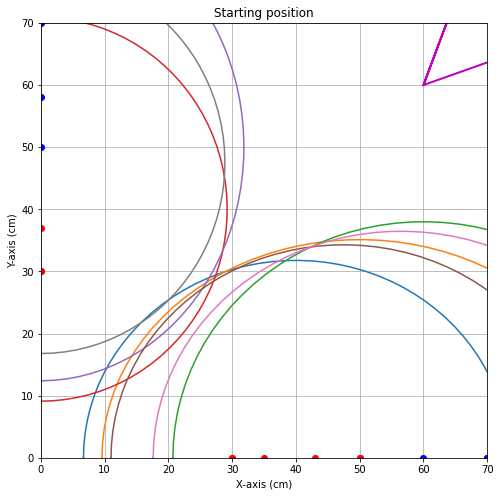


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.658


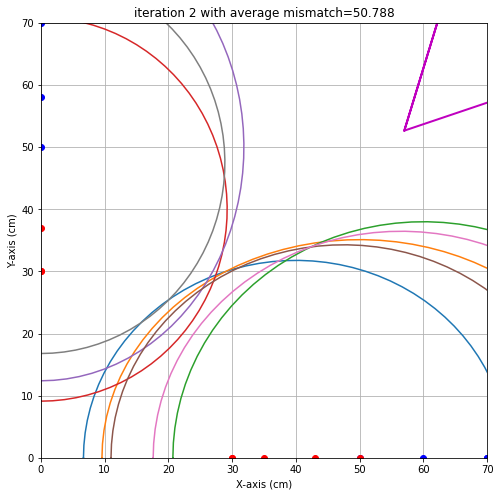

end iteration 2 with average mismatch=50.788


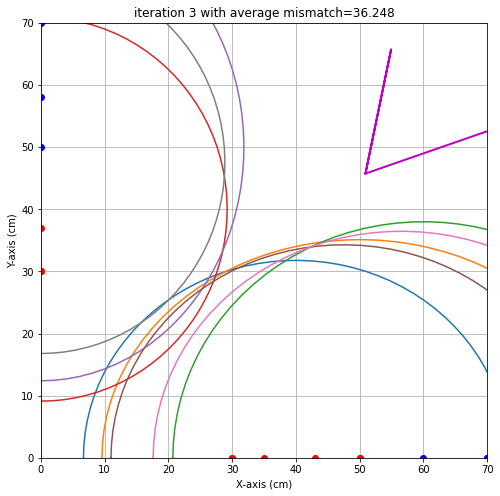

end iteration 3 with average mismatch=36.248


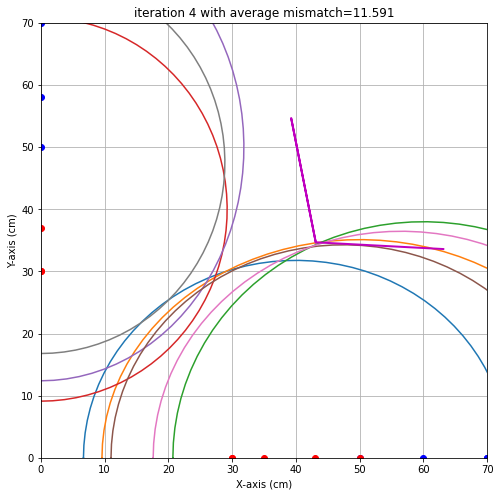

end iteration 4 with average mismatch=11.591


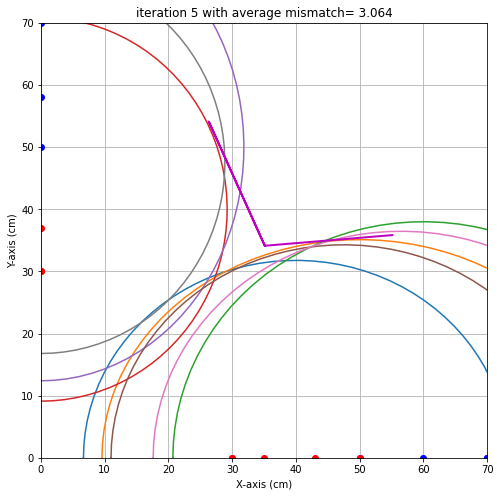

end iteration 5 with average mismatch= 3.064


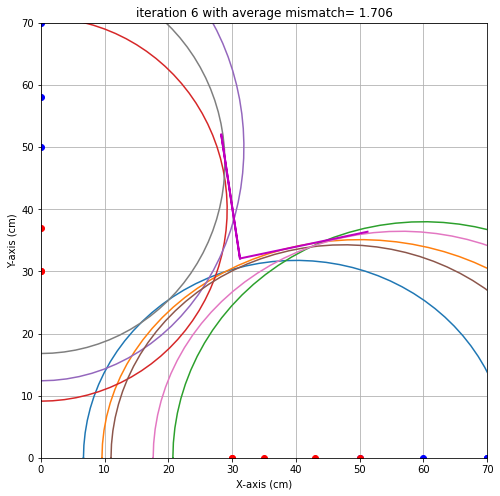

end iteration 6 with average mismatch= 1.706


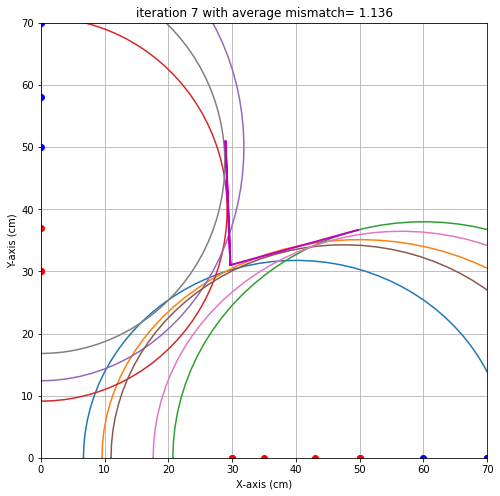

end iteration 7 with average mismatch= 1.136
end iteration 8 with average mismatch= 1.136
end iteration 9 with average mismatch= 1.136
end iteration 10 with average mismatch= 1.136
end iteration 11 with average mismatch= 1.121
end iteration 12 with average mismatch= 1.118
end iteration 13 with average mismatch= 1.117
end iteration 14 with average mismatch= 1.117
end iteration 15 with average mismatch= 1.117
end iteration 16 with average mismatch= 1.117
end iteration 17 with average mismatch= 1.117
end iteration 18 with average mismatch= 1.117
end iteration 19 with average mismatch= 1.084
end iteration 20 with average mismatch= 1.075
end iteration 21 with average mismatch= 1.073
end iteration 22 with average mismatch= 1.073
end iteration 23 with average mismatch= 1.073
end iteration 24 with average mismatch= 1.072
end iteration 25 with average mismatch= 1.070
end iteration 26 with average mismatch= 1.058
end iteration 27 with average mismatch= 1.058
end iteration 28 with average mismatc

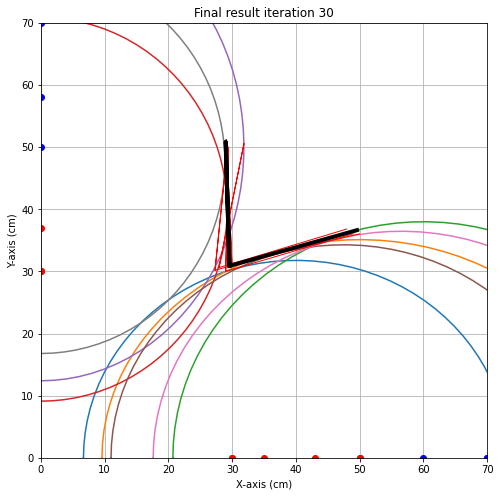

{'alpha': 16.046941421864375, 'alpha_eps': 2.5637614399448765, 'beta': -1.6775695905299517, 'beta_eps': 12.792011469360565, 'x0': 29.574099419719058, 'x0_eps': 2.259628804445615, 'y0': 30.886202854398775, 'y0_eps': 0.8619188759815231}
Erik
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  55   0  68.81
1  50   0  70   0  77.91
2   0  20   0  40  61.53
3   0  35   0  55  61.90
4  70   0  45   0  78.21
5  50   0  65   0  76.51
6  65   0  35   0  78.85
7   0  35   0  45  57.12
8   0  45   0  30  59.61


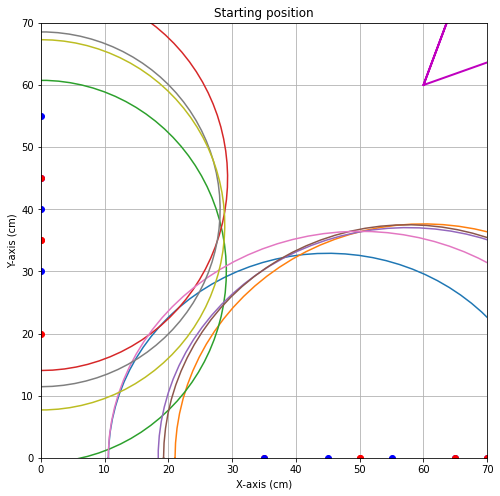


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=63.820


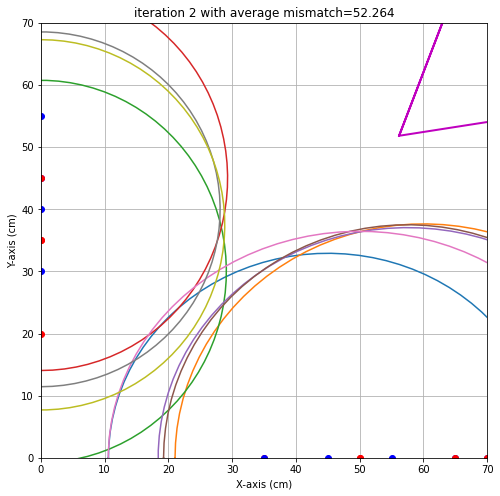

end iteration 2 with average mismatch=52.264


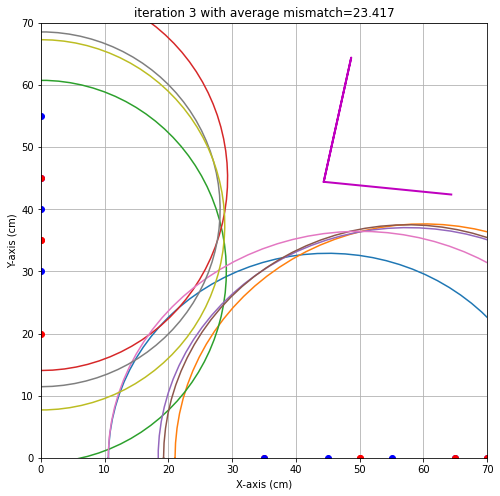

end iteration 3 with average mismatch=23.417


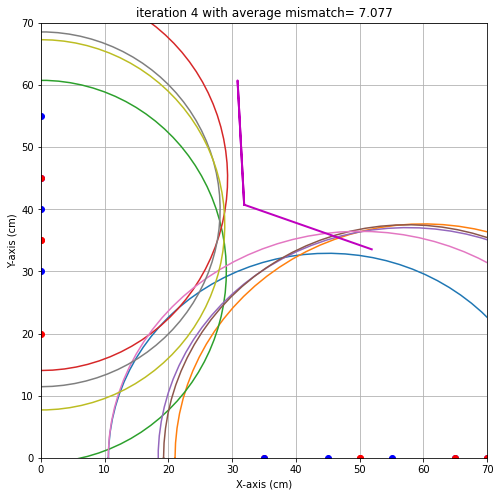

end iteration 4 with average mismatch= 7.077


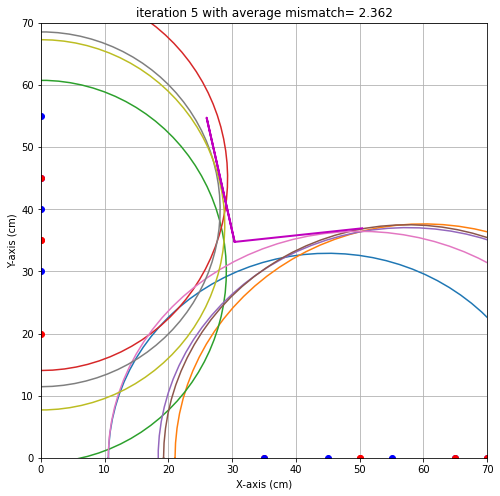

end iteration 5 with average mismatch= 2.362


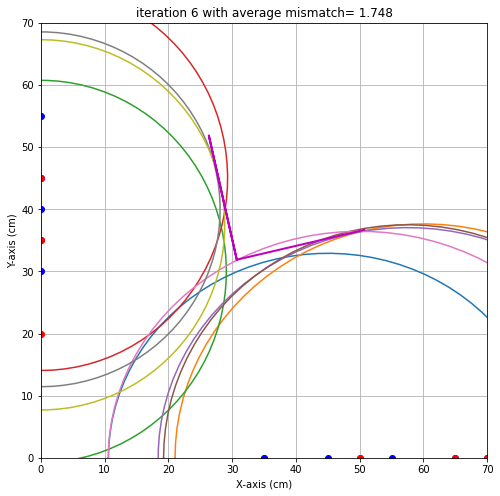

end iteration 6 with average mismatch= 1.748


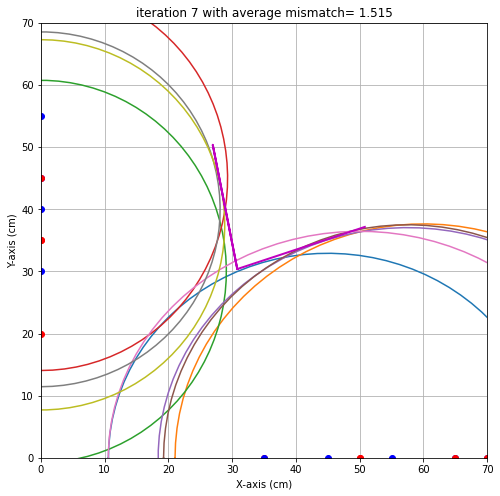

end iteration 7 with average mismatch= 1.515
end iteration 8 with average mismatch= 1.507
end iteration 9 with average mismatch= 1.493
end iteration 10 with average mismatch= 1.493


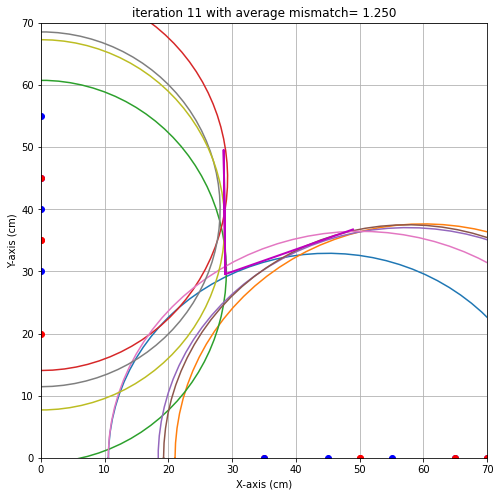

end iteration 11 with average mismatch= 1.250
end iteration 12 with average mismatch= 1.141
end iteration 13 with average mismatch= 1.134
end iteration 14 with average mismatch= 1.134
end iteration 15 with average mismatch= 1.134
end iteration 16 with average mismatch= 1.134
end iteration 17 with average mismatch= 1.134
end iteration 18 with average mismatch= 1.134
end iteration 19 with average mismatch= 1.134
end iteration 20 with average mismatch= 1.134
end iteration 21 with average mismatch= 1.134
end iteration 22 with average mismatch= 1.134
end iteration 23 with average mismatch= 1.134
end iteration 24 with average mismatch= 1.134
end iteration 25 with average mismatch= 1.134
end iteration 26 with average mismatch= 1.134
end iteration 27 with average mismatch= 1.088
end iteration 28 with average mismatch= 1.086
end iteration 29 with average mismatch= 1.086
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

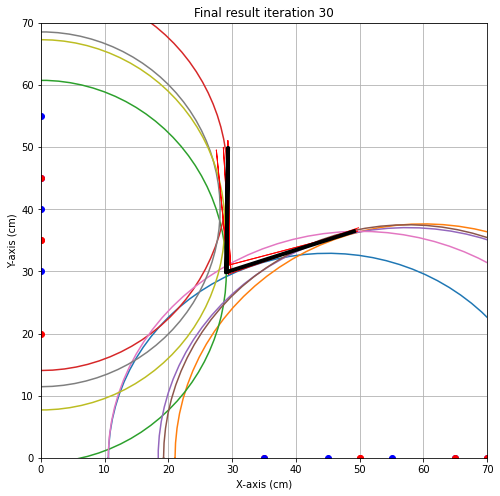

{'alpha': 18.17360525585317, 'alpha_eps': 3.028600587835655, 'beta': 0.7464922163094695, 'beta_eps': 6.213346569142786, 'x0': 29.099087606103303, 'x0_eps': 0.713866793386039, 'y0': 29.887157178221397, 'y0_eps': 1.1729693240927084}
Raphaelle


KeyError: 'Raphaelle'

In [20]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [21]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Moene 
x0 target is : 27.0. Gevonden waarde: 29.6 cm met een standaardafwijking van 2.3 cm 
y0 target is : 25.0. Gevonden waarde: 30.9 cm met een standaardafwijking van 0.9 cm 
alpha target is : 10.0. Gevonden waarde: 16.0 graden met een standaardafwijking van 2.6 graad 
beta target is : 0.0. Gevonden waarde: -1.7 graden met een standaardafwijking van 12.8 graad 

Erik 
x0 target is : 27.0. Gevonden waarde: 29.1 cm met een standaardafwijking van 0.7 cm 
y0 target is : 25.0. Gevonden waarde: 29.9 cm met een standaardafwijking van 1.2 cm 
alpha target is : 10.0. Gevonden waarde: 18.2 graden met een standaardafwijking van 3.0 graad 
beta target is : 0.0. Gevonden waarde: 0.7 graden met een standaardafwijking van 6.2 graad 



KeyError: 'Raphaelle'

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_iteratie.jpg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

Error: No connection selected.

## Opdracht 9: Iteratie 1+ meeting en test

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  47.88
1  40   0  55   0  51.26
2   0  30   0  45  58.07
3   0  40   0  55  62.91


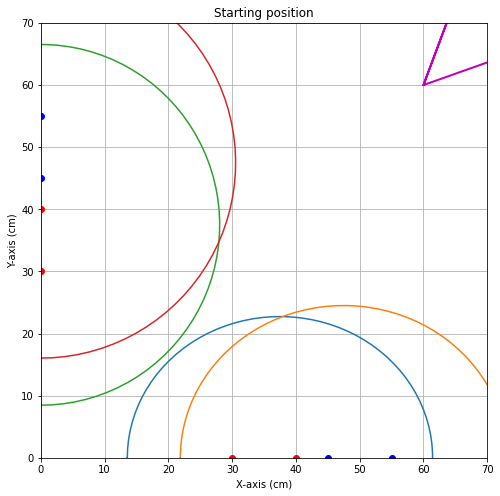


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=77.747


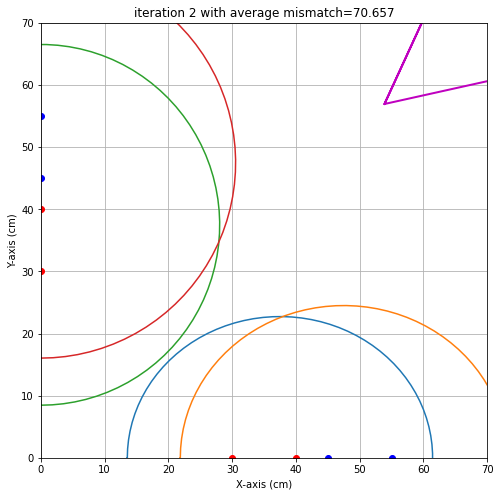

end iteration 2 with average mismatch=70.657


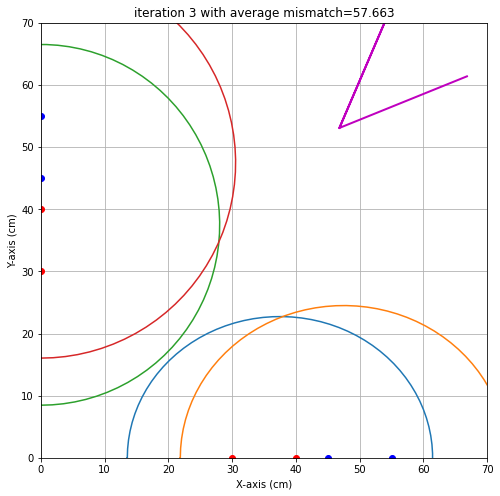

end iteration 3 with average mismatch=57.663


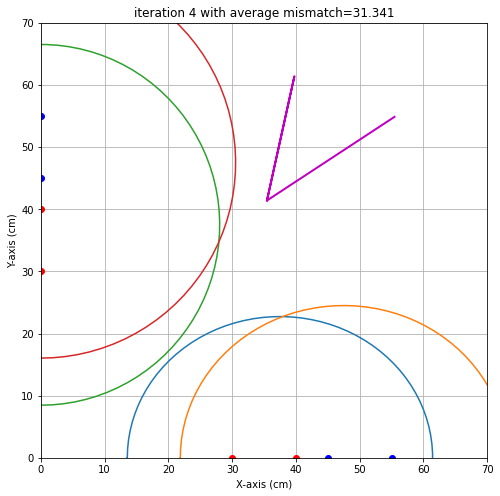

end iteration 4 with average mismatch=31.341


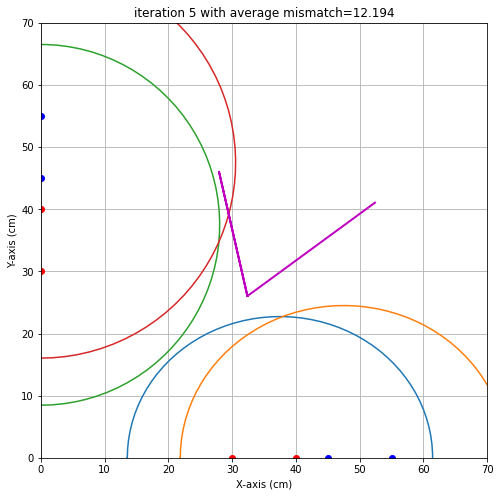

end iteration 5 with average mismatch=12.194


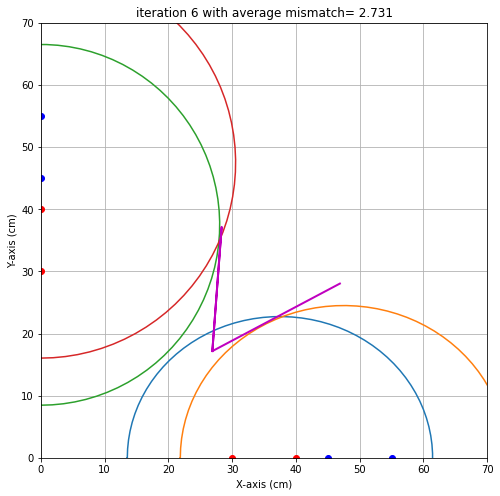

end iteration 6 with average mismatch= 2.731


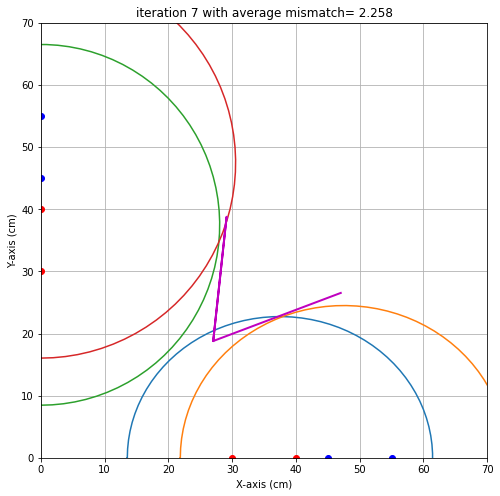

end iteration 7 with average mismatch= 2.258


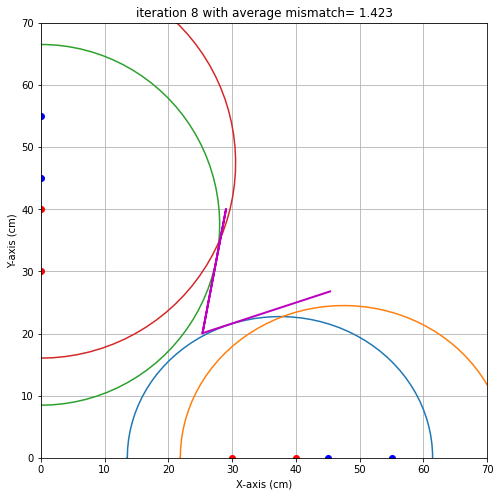

end iteration 8 with average mismatch= 1.423


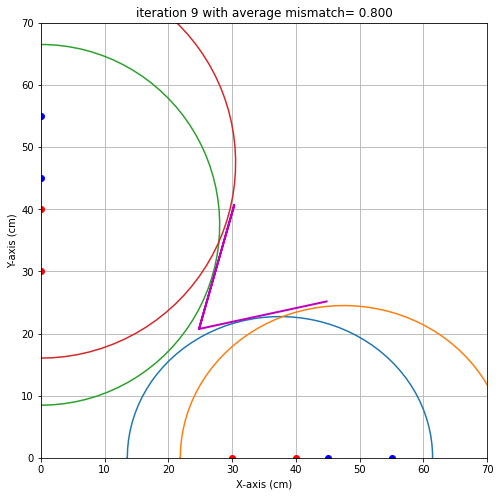

end iteration 9 with average mismatch= 0.800


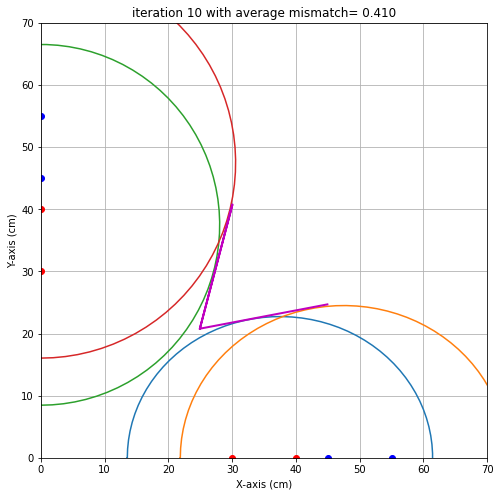

end iteration 10 with average mismatch= 0.410


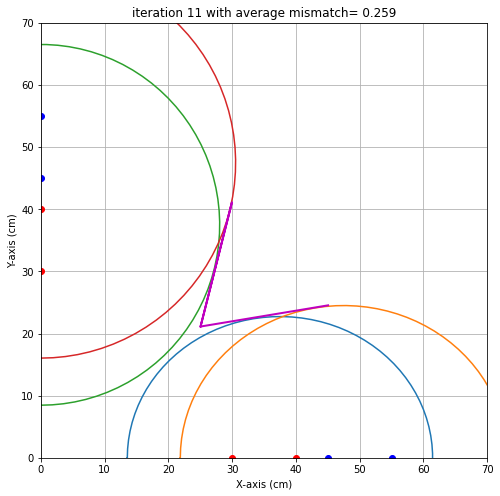

end iteration 11 with average mismatch= 0.259
end iteration 12 with average mismatch= 0.241
end iteration 13 with average mismatch= 0.224
end iteration 14 with average mismatch= 0.224
end iteration 15 with average mismatch= 0.224
end iteration 16 with average mismatch= 0.224
end iteration 17 with average mismatch= 0.224
end iteration 18 with average mismatch= 0.224
end iteration 19 with average mismatch= 0.224
end iteration 20 with average mismatch= 0.224
end iteration 21 with average mismatch= 0.224
end iteration 22 with average mismatch= 0.224
end iteration 23 with average mismatch= 0.224
end iteration 24 with average mismatch= 0.224
end iteration 25 with average mismatch= 0.224
end iteration 26 with average mismatch= 0.224
end iteration 27 with average mismatch= 0.224
end iteration 28 with average mismatch= 0.224
end iteration 29 with average mismatch= 0.224
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

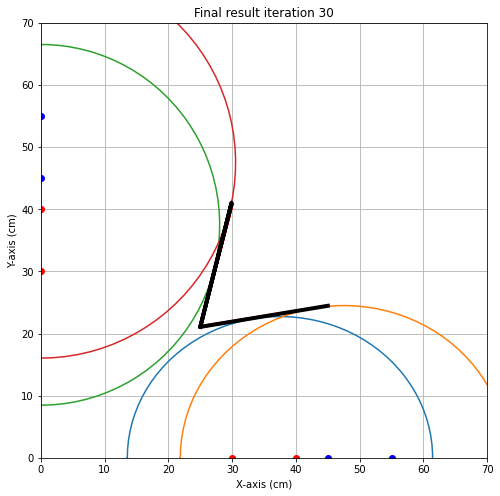

range s: x=[25.00448631 48.66545824], y=[21.06846891 44.376135  ]
range r: x=[32.3758684 57.782289 ], y=[34.1355665  61.12634853]
s pos: (32.89147695352278,0), (40.778467598335496,0), (0,28.837690943313138), (0,36.60691297217603)
r pos: (40.844675263515036,0), (49.313482131593574,0), (0,43.132493845979404), (0,52.1294211879581)


In [29]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':31,
                    'y0':33,
                    'alpha' : 9,
                    'beta' : -11},
           'locatie 2':{'x0':23,
                    'y0': 21,
                    'alpha' : -3,
                    'beta' : 11}
           }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,76.53],
    [50,0,65,0,81.25],
    [40,0,55,0,77.01],
    [0,30,0,45,66.18],
    [0,40,0,55,63.01]
    #[0,50,0,65,-]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,47.88],
    #[50,0,65,0,-],
    [40,0,55,0,51.26],
    [0,30,0,45,58.07],
    [0,40,0,55,62.91]
    #[0,50,0,65,-]
    ])
      }


rough_location = imagingDEF.imagingDEF(data['locatie 2'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        

In [30]:
data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,76.53],
    [50,0,65,0,81.25],
    [40,0,55,0,77.01],
    [0,30,0,45,66.18],
    [0,40,0,55,63.01],
    #[0,50,0,65]
    [41,0,56,0,77.67],
    [49,0,65,0,81.35],
    [0,44,0,33,65.04],
    [0,52,0,41,61.60]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,47.88],
    #[50,0,65,0,-],
    [40,0,55,0,51.26],
    [0,30,0,45,58.07],
    [0,40,0,55,62.91],
    #[0,50,0,65,-]
    [33,0,41,0,45.29],
    [41,0,49,0,45.52],
    [0,29,0,43,56.51],
    [0,37,0,52,60.90]
    ])
      }

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  76.53
1  50   0  65   0  81.25
2  40   0  55   0  77.01
3   0  30   0  45  66.18
4   0  40   0  55  63.01
5  41   0  56   0  77.67
6  49   0  65   0  81.35
7   0  44   0  33  65.04
8   0  52   0  41  61.60


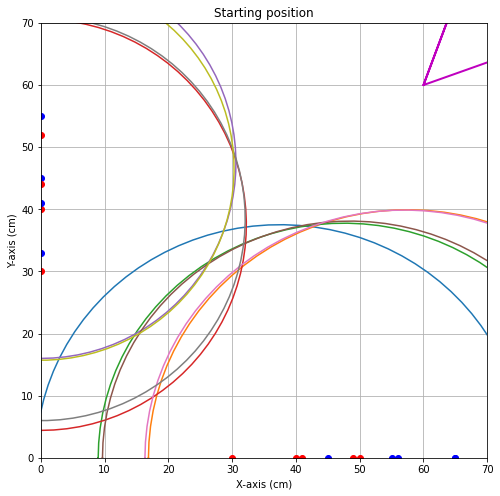


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.259


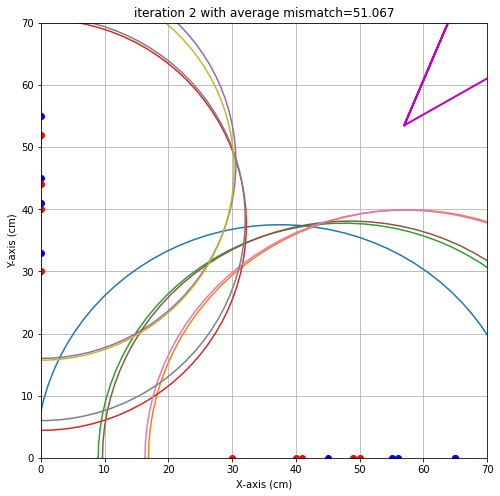

end iteration 2 with average mismatch=51.067


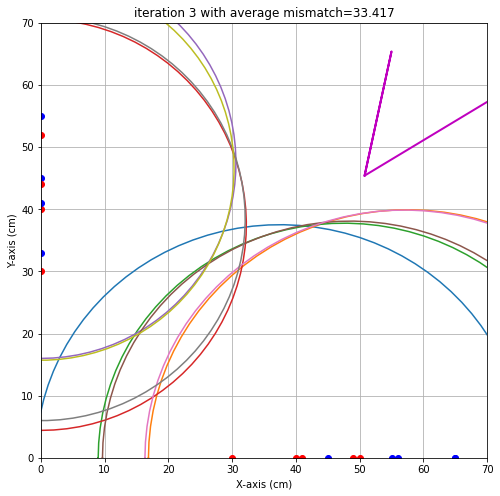

end iteration 3 with average mismatch=33.417


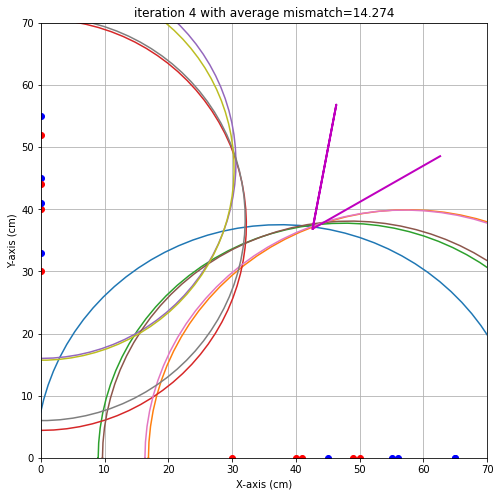

end iteration 4 with average mismatch=14.274


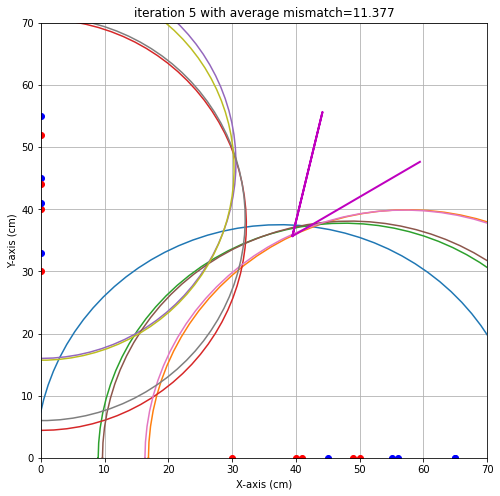

end iteration 5 with average mismatch=11.377


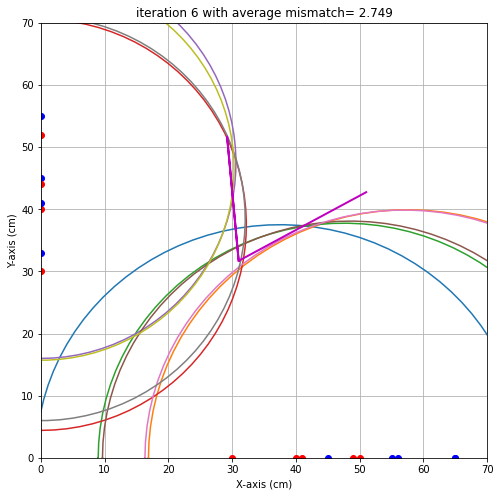

end iteration 6 with average mismatch= 2.749
end iteration 7 with average mismatch= 2.749


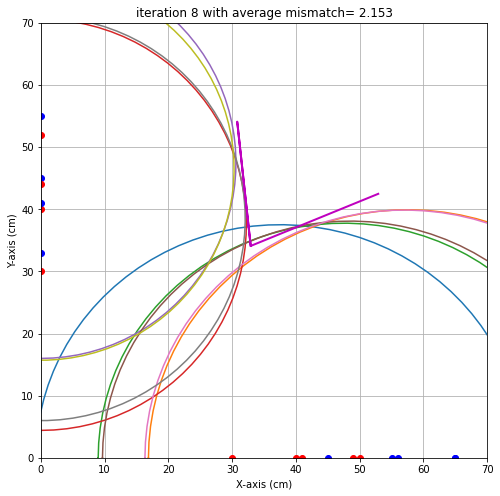

end iteration 8 with average mismatch= 2.153


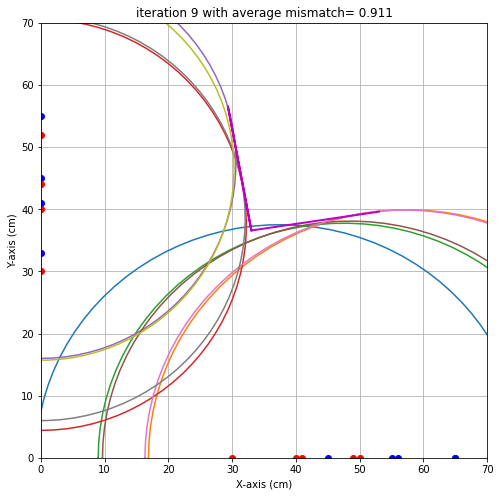

end iteration 9 with average mismatch= 0.911


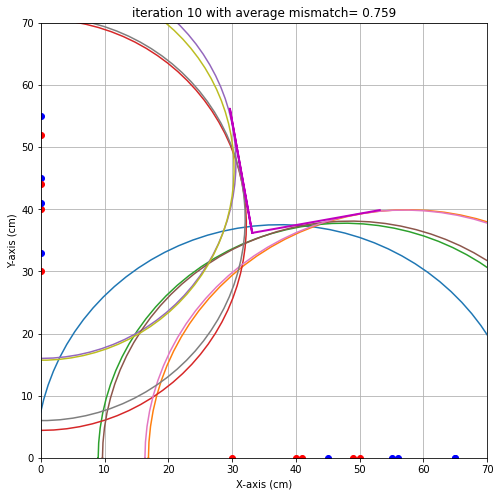

end iteration 10 with average mismatch= 0.759
end iteration 11 with average mismatch= 0.756
end iteration 12 with average mismatch= 0.747
end iteration 13 with average mismatch= 0.747
end iteration 14 with average mismatch= 0.746
end iteration 15 with average mismatch= 0.706
end iteration 16 with average mismatch= 0.701
end iteration 17 with average mismatch= 0.701
end iteration 18 with average mismatch= 0.701
end iteration 19 with average mismatch= 0.701
end iteration 20 with average mismatch= 0.701
end iteration 21 with average mismatch= 0.701
end iteration 22 with average mismatch= 0.701
end iteration 23 with average mismatch= 0.701
end iteration 24 with average mismatch= 0.701
end iteration 25 with average mismatch= 0.701
end iteration 26 with average mismatch= 0.701
end iteration 27 with average mismatch= 0.701
end iteration 28 with average mismatch= 0.701
end iteration 29 with average mismatch= 0.701
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

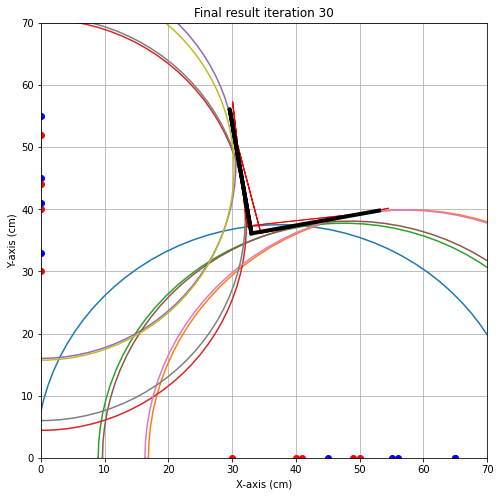

{'alpha': 10.391207247696487, 'alpha_eps': 3.981354969553383, 'beta': -9.699397950446174, 'beta_eps': 4.733939962124177, 'x0': 33.03178082408111, 'x0_eps': 1.4793049061965178, 'y0': 36.123327447154075, 'y0_eps': 1.176033847153228}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  47.88
1  40   0  55   0  51.26
2   0  30   0  45  58.07
3   0  40   0  55  62.91
4  33   0  41   0  45.29
5  41   0  49   0  45.52
6   0  29   0  43  56.51
7   0  37   0  52  60.90


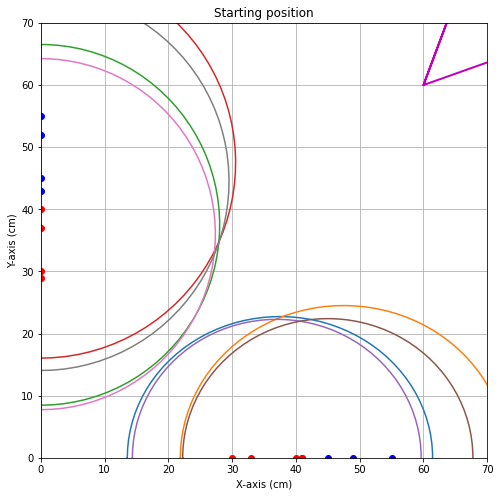


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.639


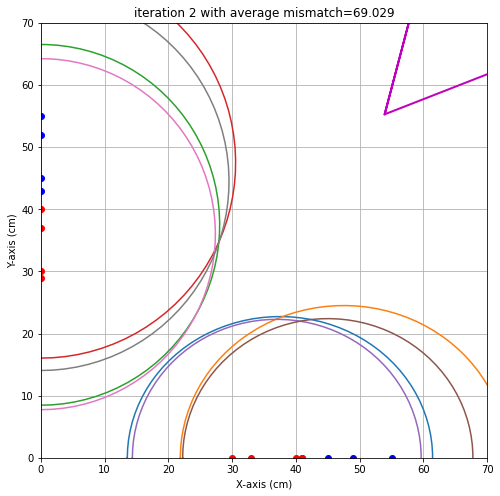

end iteration 2 with average mismatch=69.029


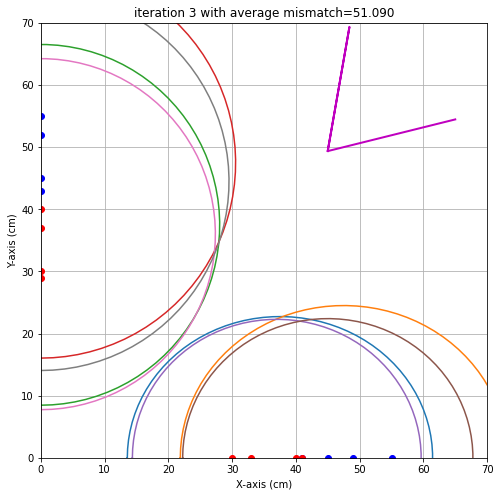

end iteration 3 with average mismatch=51.090


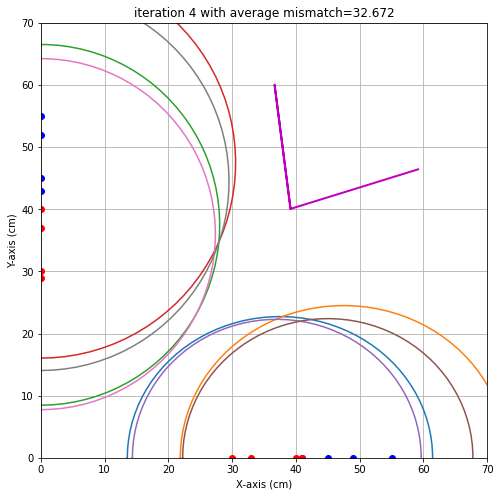

end iteration 4 with average mismatch=32.672


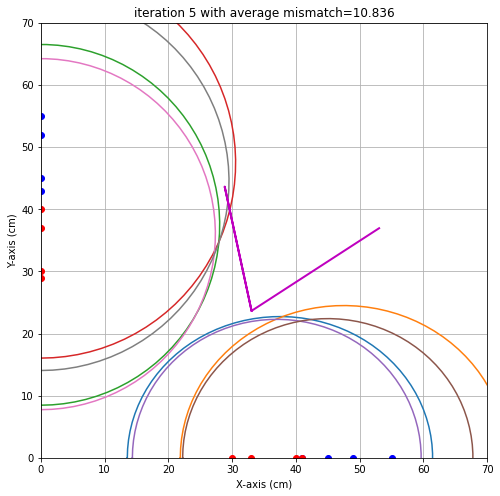

end iteration 5 with average mismatch=10.836


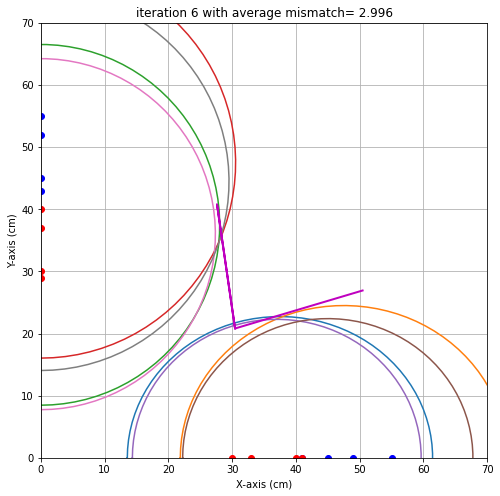

end iteration 6 with average mismatch= 2.996


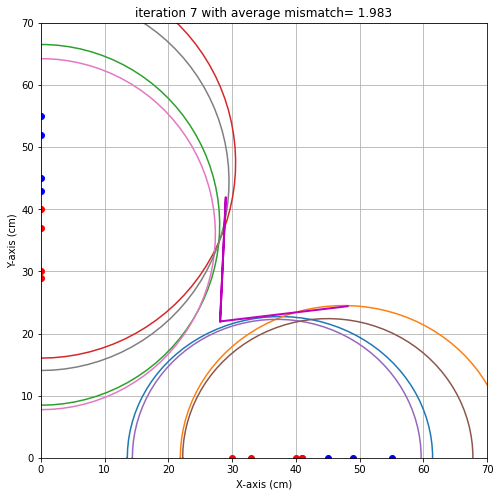

end iteration 7 with average mismatch= 1.983


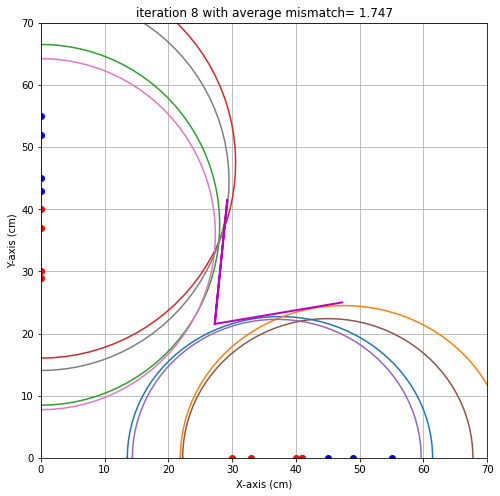

end iteration 8 with average mismatch= 1.747


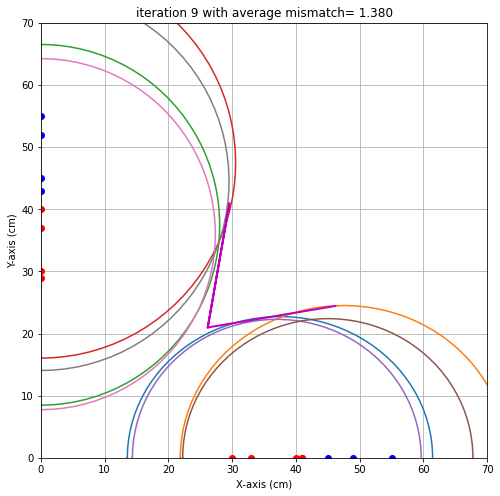

end iteration 9 with average mismatch= 1.380


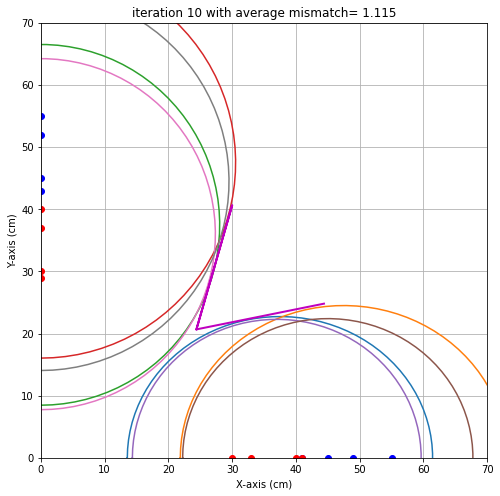

end iteration 10 with average mismatch= 1.115
end iteration 11 with average mismatch= 1.016
end iteration 12 with average mismatch= 0.980
end iteration 13 with average mismatch= 0.968
end iteration 14 with average mismatch= 0.916
end iteration 15 with average mismatch= 0.916
end iteration 16 with average mismatch= 0.903
end iteration 17 with average mismatch= 0.903
end iteration 18 with average mismatch= 0.903
end iteration 19 with average mismatch= 0.903
end iteration 20 with average mismatch= 0.903
end iteration 21 with average mismatch= 0.903
end iteration 22 with average mismatch= 0.903
end iteration 23 with average mismatch= 0.903
end iteration 24 with average mismatch= 0.903
end iteration 25 with average mismatch= 0.903
end iteration 26 with average mismatch= 0.903
end iteration 27 with average mismatch= 0.903
end iteration 28 with average mismatch= 0.903
end iteration 29 with average mismatch= 0.903
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

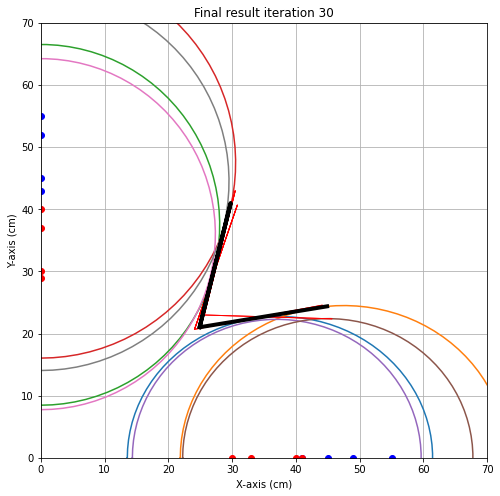

{'alpha': 9.559990248462428, 'alpha_eps': 11.319852715592612, 'beta': 13.717495159145749, 'beta_eps': 4.8376424869336745, 'x0': 24.89439344357812, 'x0_eps': 0.7868513326602802, 'y0': 21.01339031851427, 'y0_eps': 1.973326000199222}
locatie 1 
x0 target is : 31.0. Gevonden waarde: 33.0 cm met een standaardafwijking van 1.5 cm 
y0 target is : 33.0. Gevonden waarde: 36.1 cm met een standaardafwijking van 1.2 cm 
alpha target is : 9.0. Gevonden waarde: 10.4 graden met een standaardafwijking van 4.0 graad 
beta target is : -11.0. Gevonden waarde: -9.7 graden met een standaardafwijking van 4.7 graad 

locatie 2 
x0 target is : 23.0. Gevonden waarde: 24.9 cm met een standaardafwijking van 0.8 cm 
y0 target is : 21.0. Gevonden waarde: 21.0 cm met een standaardafwijking van 2.0 cm 
alpha target is : -3.0. Gevonden waarde: 9.6 graden met een standaardafwijking van 11.3 graad 
beta target is : 11.0. Gevonden waarde: 13.7 graden met een standaardafwijking van 4.8 graad 



In [ ]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])
    x0=rough_location['x0']
    y0=rough_location['y0']
    alpha=rough_location['alpha']
    beta=rough_location['beta']
    
    

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_iteratie2.jpeg)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

Error: No connection selected.

## Opdracht 9: Iteratie 1+ meeting en test

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  45   0  91.35
1  50   0  65   0  93.15
2  40   0  55   0  89.86
3  45   0  30   0  90.53
4   0  30   0  45  65.41
5   0  40   0  55  60.45
6   0  45   0  30  63.59


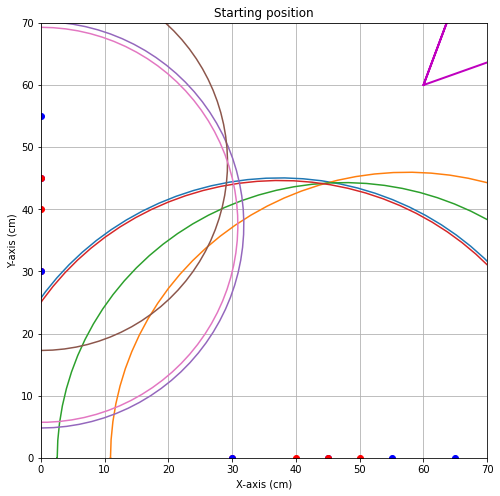


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=54.042


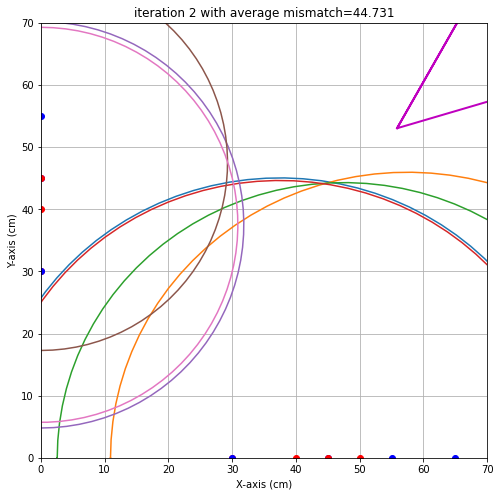

end iteration 2 with average mismatch=44.731


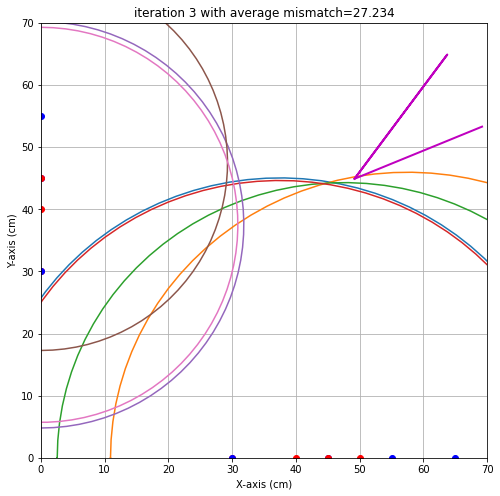

end iteration 3 with average mismatch=27.234


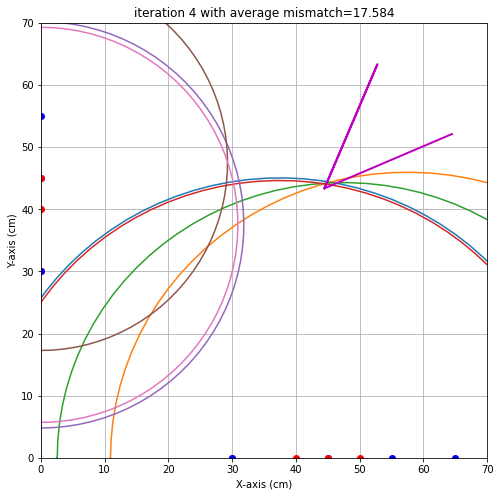

end iteration 4 with average mismatch=17.584


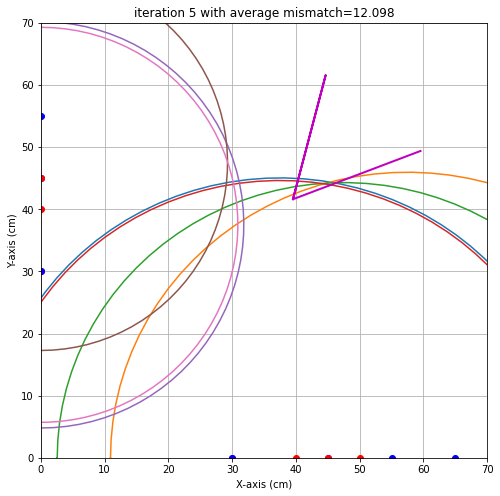

end iteration 5 with average mismatch=12.098


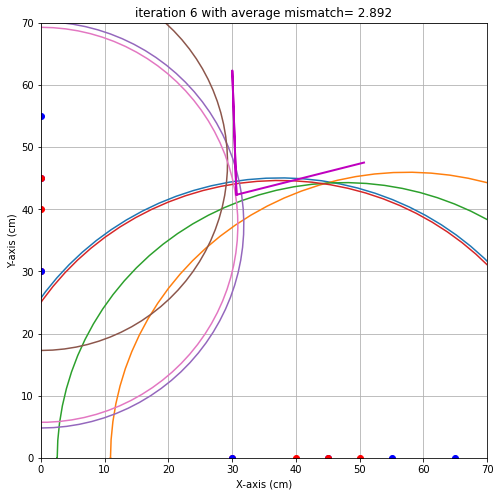

end iteration 6 with average mismatch= 2.892


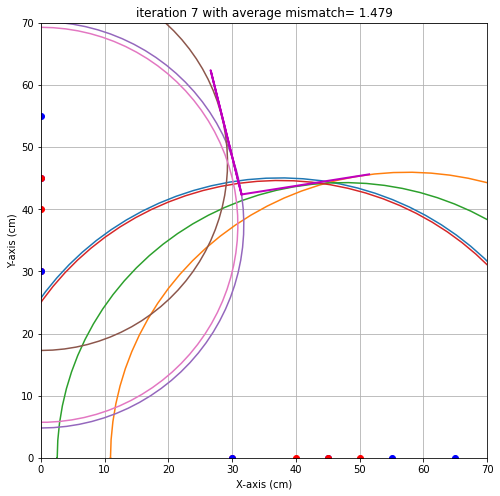

end iteration 7 with average mismatch= 1.479
end iteration 8 with average mismatch= 1.454
end iteration 9 with average mismatch= 1.442


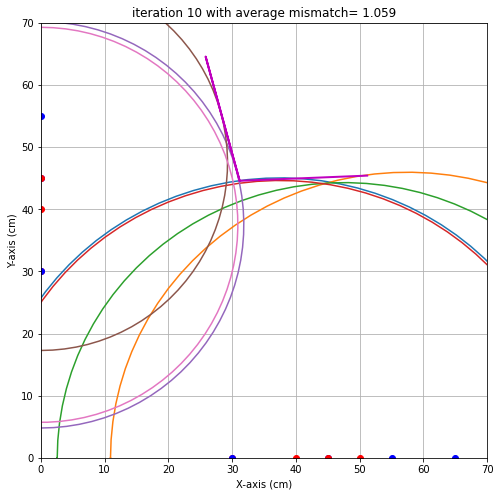

end iteration 10 with average mismatch= 1.059
end iteration 11 with average mismatch= 1.036
end iteration 12 with average mismatch= 1.035
end iteration 13 with average mismatch= 1.035
end iteration 14 with average mismatch= 1.035
end iteration 15 with average mismatch= 1.035
end iteration 16 with average mismatch= 1.035
end iteration 17 with average mismatch= 1.035
end iteration 18 with average mismatch= 1.035
end iteration 19 with average mismatch= 1.035
end iteration 20 with average mismatch= 1.035
end iteration 21 with average mismatch= 1.035
end iteration 22 with average mismatch= 1.035
end iteration 23 with average mismatch= 1.035
end iteration 24 with average mismatch= 1.035
end iteration 25 with average mismatch= 1.035
end iteration 26 with average mismatch= 1.035
end iteration 27 with average mismatch= 1.035
end iteration 28 with average mismatch= 1.035
end iteration 29 with average mismatch= 1.035
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

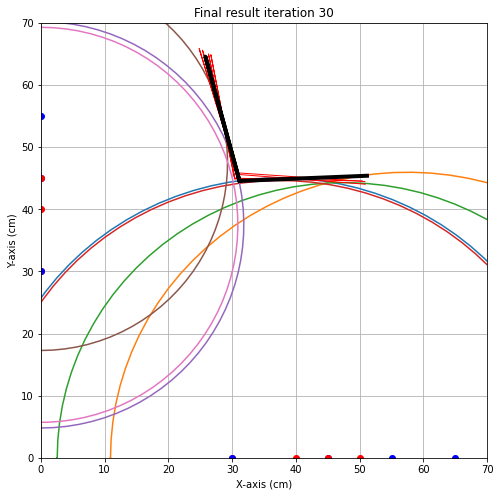

range s: x=[31.14627856 55.12547047], y=[44.56621673 67.7540529 ]
range r: x=[34.86675426 58.95016755], y=[26.65904975 54.21829221]
s pos: (39.139342527565226,0), (47.1324064984173,0), (0,52.29549545129192), (0,60.02477417507585)
r pos: (42.894558688053706,0), (50.92236311806526,0), (0,35.84546390555817), (0,45.0318780568475)


In [36]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':24,
                    'y0':29.5,
                    'alpha' : 10,
                    'beta' : 5},
           'locatie 2':{'x0':32,
                    'y0': 39.5,
                    'alpha' : 14,
                    'beta' : -15}
           }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,65.41],
    #[50,0,65,0,-],
    [40,0,55,0,69.32],
    [45,0,30,0,65.51],
    [0,30,0,45,51.15],
    [0,40,0,55,52.84],
    [0,50,0,65,58.06],
    [0,45,0,30,50.71]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,91.35],
    [50,0,65,0,93.15],
    [40,0,55,0,89.86],
    [45,0,30,0,90.53],
    [0,30,0,45,65.41],
    [0,40,0,55,60.45],
    #[0,50,0,65,-],
    [0,45,0,30,63.59]
    ])
      }


rough_location = imagingDEF.imagingDEF(data['locatie 2'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        

In [39]:
data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,45,0,65.41],
    #[50,0,65,0,-],
    [40,0,55,0,69.32],
    [45,0,30,0,65.51],
    [0,30,0,45,51.15],
    [0,40,0,55,52.84],
    [0,50,0,65,58.06],
    [0,45,0,30,50.71],
    [31,0,44,0,64.60],
    [39,0,53,0,68.5],
    [0,38,0,47,50.3],
    [0,46,0,55,51.7]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,45,0,91.35],
    [50,0,65,0,93.15],
    [40,0,55,0,89.86],
    #[45,0,30,0,90.53],
    [0,30,0,45,65.41],
    [0,40,0,55,60.45],
    #[0,50,0,65,-],
    [0,45,0,30,63.59],
    [39,0,49,0,87.55],
    [47,0,57,0,90.08],
    [0,52,0,36,63.15],
    [0,60,0,45,59.09]
    ])
      }

locatie 1
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0   30   0  45   0  65.41
1   40   0  55   0  69.32
2   45   0  30   0  65.51
3    0  30   0  45  51.15
4    0  40   0  55  52.84
5    0  50   0  65  58.06
6    0  45   0  30  50.71
7   31   0  44   0  64.60
8   39   0  53   0  68.50
9    0  38   0  47  50.30
10   0  46   0  55  51.70


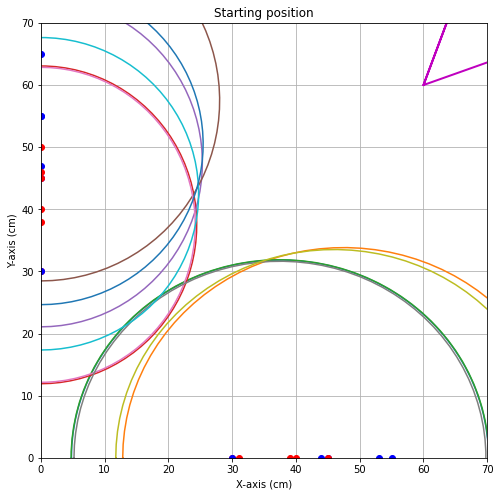


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=72.982


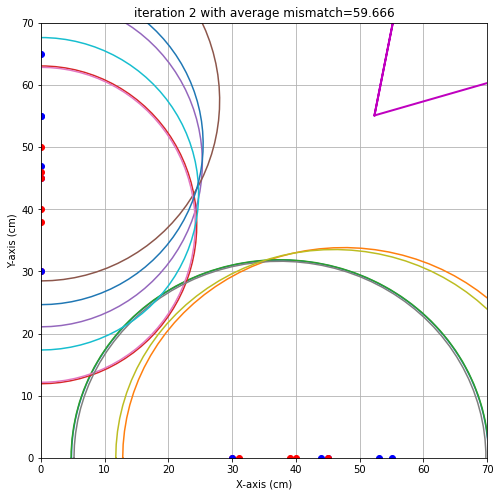

end iteration 2 with average mismatch=59.666


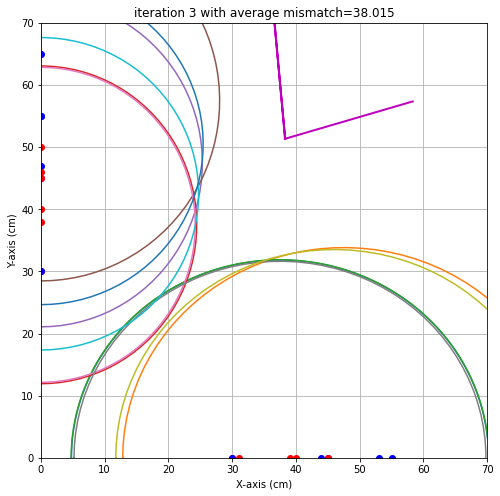

end iteration 3 with average mismatch=38.015


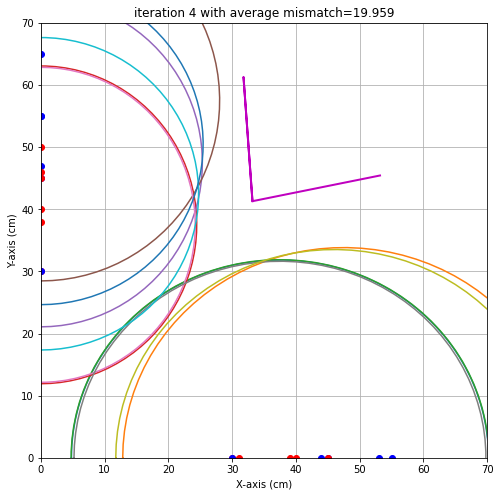

end iteration 4 with average mismatch=19.959


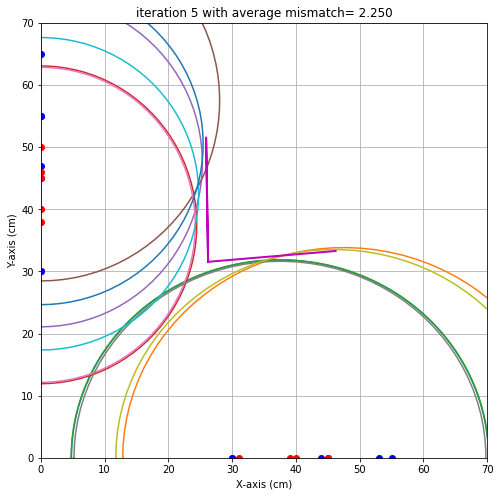

end iteration 5 with average mismatch= 2.250


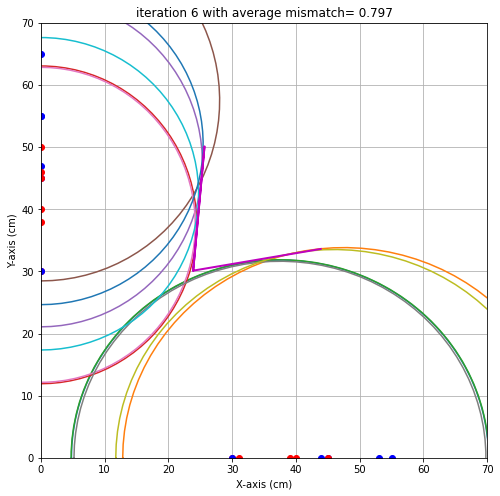

end iteration 6 with average mismatch= 0.797
end iteration 7 with average mismatch= 0.797
end iteration 8 with average mismatch= 0.797
end iteration 9 with average mismatch= 0.797
end iteration 10 with average mismatch= 0.797
end iteration 11 with average mismatch= 0.733
end iteration 12 with average mismatch= 0.717
end iteration 13 with average mismatch= 0.716
end iteration 14 with average mismatch= 0.716
end iteration 15 with average mismatch= 0.715
end iteration 16 with average mismatch= 0.679
end iteration 17 with average mismatch= 0.671
end iteration 18 with average mismatch= 0.667
end iteration 19 with average mismatch= 0.667
end iteration 20 with average mismatch= 0.667
end iteration 21 with average mismatch= 0.667
end iteration 22 with average mismatch= 0.667
end iteration 23 with average mismatch= 0.667
end iteration 24 with average mismatch= 0.667
end iteration 25 with average mismatch= 0.667
end iteration 26 with average mismatch= 0.667
end iteration 27 with average mismatch

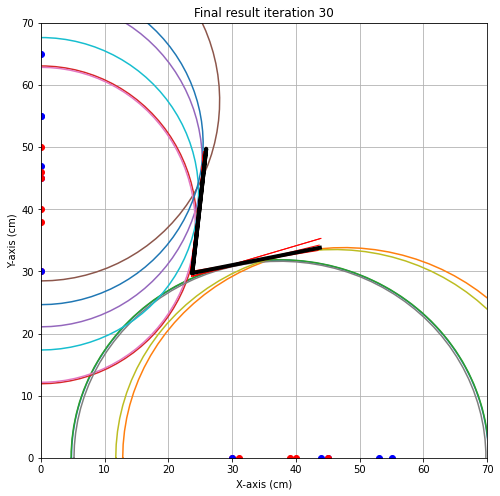

{'alpha': 11.486121403622365, 'alpha_eps': 5.328610291080993, 'beta': 6.230282530942705, 'beta_eps': 1.6147782652278453, 'x0': 23.75562100994745, 'x0_eps': 0.28921161794732697, 'y0': 29.744362731187152, 'y0_eps': 0.5332200807699081}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  50   0  65   0  93.15
1  40   0  55   0  89.86
2   0  30   0  45  65.41
3   0  40   0  55  60.45
4   0  45   0  30  63.59
5  39   0  49   0  87.55
6  47   0  57   0  90.08
7   0  52   0  36  63.15
8   0  60   0  45  59.09


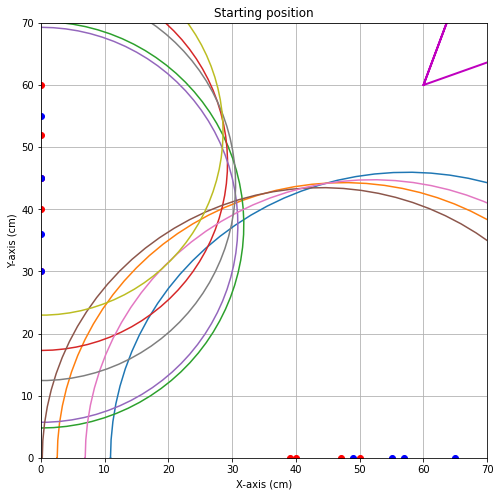


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.833


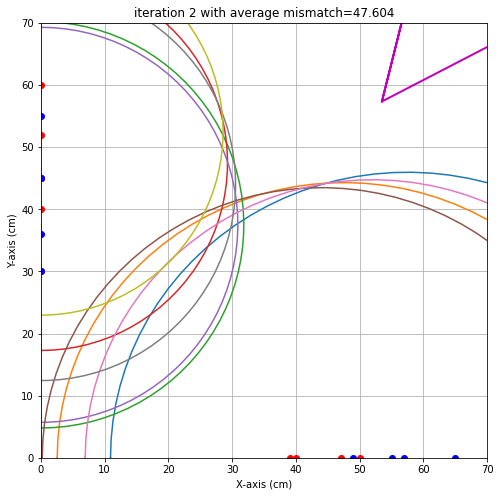

end iteration 2 with average mismatch=47.604


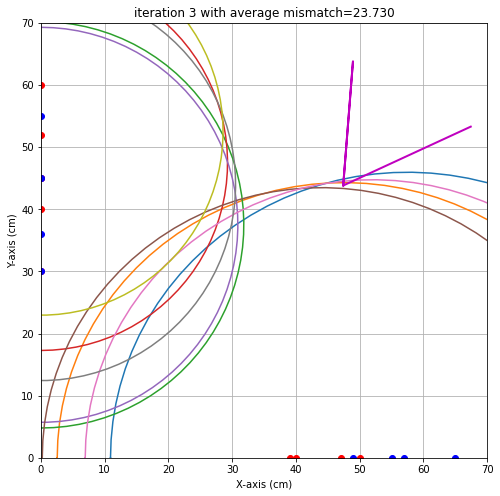

end iteration 3 with average mismatch=23.730


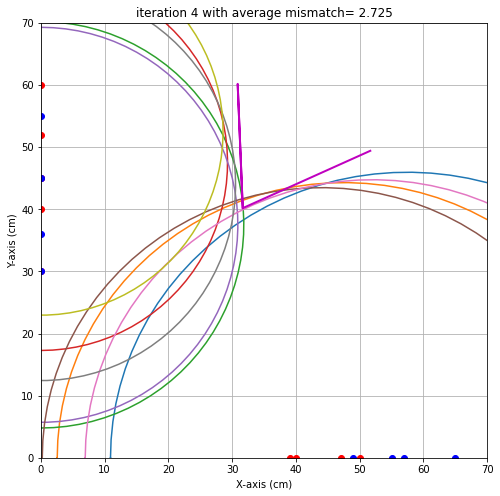

end iteration 4 with average mismatch= 2.725


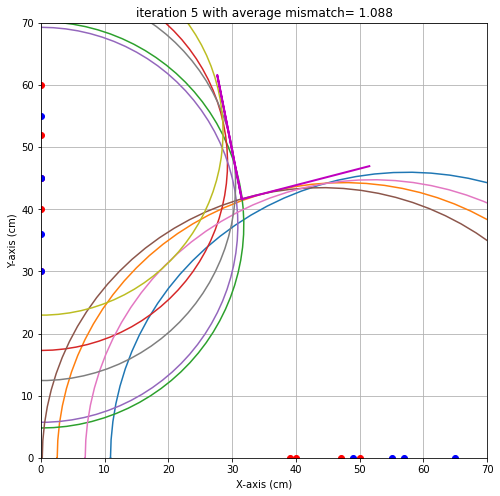

end iteration 5 with average mismatch= 1.088


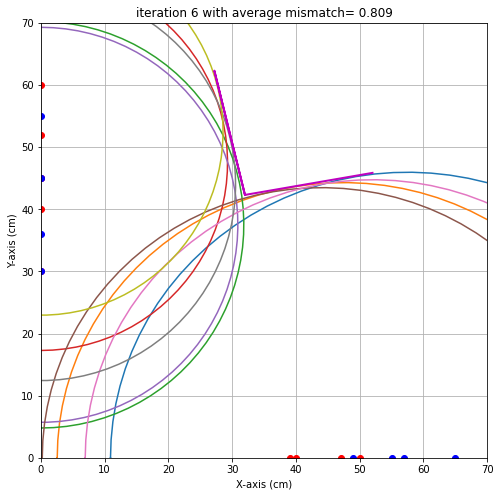

end iteration 6 with average mismatch= 0.809
end iteration 7 with average mismatch= 0.734
end iteration 8 with average mismatch= 0.674
end iteration 9 with average mismatch= 0.661
end iteration 10 with average mismatch= 0.654
end iteration 11 with average mismatch= 0.653
end iteration 12 with average mismatch= 0.653
end iteration 13 with average mismatch= 0.652
end iteration 14 with average mismatch= 0.652
end iteration 15 with average mismatch= 0.652
end iteration 16 with average mismatch= 0.652
end iteration 17 with average mismatch= 0.652
end iteration 18 with average mismatch= 0.652
end iteration 19 with average mismatch= 0.652
end iteration 20 with average mismatch= 0.652
end iteration 21 with average mismatch= 0.652
end iteration 22 with average mismatch= 0.652
end iteration 23 with average mismatch= 0.652
end iteration 24 with average mismatch= 0.652
end iteration 25 with average mismatch= 0.652
end iteration 26 with average mismatch= 0.652
end iteration 27 with average mismatch

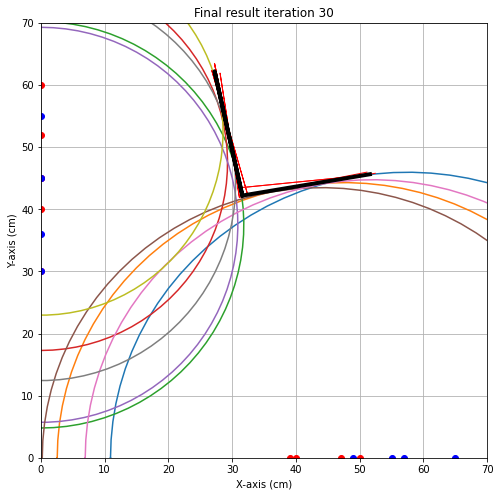

{'alpha': 9.738247707566268, 'alpha_eps': 3.9072710186730566, 'beta': -12.29236090890457, 'beta_eps': 3.6676796891367527, 'x0': 31.60204171610572, 'x0_eps': 0.8379236376195358, 'y0': 42.2122998379473, 'y0_eps': 1.2660647384835215}
locatie 1 
x0 target is : 24.0. Gevonden waarde: 23.8 cm met een standaardafwijking van 0.3 cm 
y0 target is : 29.5. Gevonden waarde: 29.7 cm met een standaardafwijking van 0.5 cm 
alpha target is : 10.0. Gevonden waarde: 11.5 graden met een standaardafwijking van 5.3 graad 
beta target is : 5.0. Gevonden waarde: 6.2 graden met een standaardafwijking van 1.6 graad 

locatie 2 
x0 target is : 32.0. Gevonden waarde: 31.6 cm met een standaardafwijking van 0.8 cm 
y0 target is : 39.5. Gevonden waarde: 42.2 cm met een standaardafwijking van 1.3 cm 
alpha target is : 14.0. Gevonden waarde: 9.7 graden met een standaardafwijking van 3.9 graad 
beta target is : -15.0. Gevonden waarde: -12.3 graden met een standaardafwijking van 3.7 graad 



In [40]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])
    x0=rough_location['x0']
    y0=rough_location['y0']
    alpha=rough_location['alpha']
    beta=rough_location['beta']
    
    

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,45,0,65.41],
                    [40,0,55,0,69.32],
                    [50,0,65,0,-],
                    [45,0,30,0,65.51],
                    [0,30,0,45,51.15],
                    [0,40,0,55,52.84],
                    [0,50,0,65,58.06],
                    [0,45,0,30,50.71]
                    ])
                }


rough_location = imagingDEF.imagingDEF(data['locatie 2'])
x0=rough_location['x0']
y0=rough_location['y0']
alpha=rough_location['alpha']
beta=rough_location['beta']

x_range_s = np.array([x0,x0+24*np.cos(alpha/180 * np.pi)])
y_range_s = np.array([y0,y0+24*np.cos(beta/180 *np.pi)])
x_range_r = np.array([x0+y0*np.tan((2*alpha)/180 * np.pi),x0+24+(y0+24*np.sin(alpha/180 * np.pi))*np.tan((2*alpha)/180 * np.pi)])
y_range_r = np.array([y0+x0*np.tan((2*beta)/180 * np.pi),y0+24+(x0+24*np.sin(beta/180 * np.pi))*np.tan((2*beta)/180 * np.pi)])

print(f'range s: x={x_range_s}, y={y_range_s}')
print(f'range r: x={x_range_r}, y={y_range_r}')
print(f's pos: ({(x_range_s[1]-x_range_s[0])/3 + x_range_s[0]},0), ({(x_range_s[1]-x_range_s[0])*2/3 + x_range_s[0]},0), (0,{(y_range_s[1]-y_range_s[0])/3 + y_range_s[0]}), (0,{(y_range_s[1]-y_range_s[0])*2/3 + y_range_s[0]})')
print(f'r pos: ({(x_range_r[1]-x_range_r[0])/3 + x_range_r[0]},0), ({(x_range_r[1]-x_range_r[0])*2/3 + x_range_r[0]},0), (0,{(y_range_r[1]-y_range_r[0])/3 + y_range_r[0]}), (0,{(y_range_r[1]-y_range_r[0])*2/3 + y_range_r[0]})')                        


Error: No connection selected.

In [ ]:
dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,45,0,65.41],
                    [50,0,65,0,-],
                    [40,0,55,0,69.32],
                    [45,0,30,0,65.51],
                    [0,30,0,45,51.15],
                    [0,40,0,55,52.84],
                    [0,50,0,65,58.06],
                    [0,45,0,30,50.71]
                    ])
                }

In [ ]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")